# Smartphones

Today the smartphone market seems to be saturated with so many options. This is why we will use a database with a collection of smartphones to analyse the relationship of their components and the price. In this notebook we prepared the data taht was used for that study, with the final result being a csv file with clean data.

## 1. Data Exploration, Visualisations, and Summary:
- Download the dataset, prepare a summary of features, including data type
(numerical/categorical), and assess the amount of missing data and outliers in
individual features. Conduct initial exploration with visualisation and statistical
analysis of the features.
- Introduce the dataset in your report including any interesting visualisations. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

smartphones= pd.read_csv('smartphones!.csv')

In [2]:
smartphones = smartphones.rename(columns={'processor_speed': 'processor_s', 'ear_cam': 'rear_cam'})

In [3]:
smartphones.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price,54999,19989,16499,14999,24999
price_GBP,522,190,157,142,237
rating,89.0,81.0,75.0,81.0,82.0
5g,True,True,True,True,True
nfc,True,False,False,False,False
ir_blst,False,False,False,False,False
processor_b,snapdragon,snapdragon,exynos,snapdragon,dimensity
cores,8.0,8.0,8.0,8.0,8.0


In [4]:
smartphones.shape

(980, 27)

In [5]:
smartphones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         980 non-null    object 
 1   model         980 non-null    object 
 2   price         980 non-null    int64  
 3   price_GBP     980 non-null    int64  
 4   rating        879 non-null    float64
 5   5g            980 non-null    bool   
 6   nfc           980 non-null    bool   
 7   ir_blst       980 non-null    bool   
 8   processor_b   960 non-null    object 
 9   cores         974 non-null    float64
 10  processor_s   938 non-null    float64
 11  battery       969 non-null    float64
 12  fast_a        980 non-null    int64  
 13  fast          769 non-null    float64
 14  ram           980 non-null    int64  
 15  memory        980 non-null    int64  
 16  screen        980 non-null    float64
 17  refresh_r     980 non-null    int64  
 18  rear_cam      980 non-null    

In [6]:
missing_values = smartphones.isnull().sum()
print('\nMissing values per feature:')
print(missing_values)


Missing values per feature:
brand             0
model             0
price             0
price_GBP         0
rating          101
5g                0
nfc               0
ir_blst           0
processor_b      20
cores             6
processor_s      42
battery          11
fast_a            0
fast            211
ram               0
memory            0
screen            0
refresh_r         0
rear_cam          0
front_cam         4
os               14
res_rc            0
res_fc            5
extnd_memory      0
extnd_upto      480
res_width         0
res_height        0
dtype: int64


In [7]:
COLUMNS = ['brand', 'model', 'rating', '5g', 'nfc', 
           'ir_blst', 'processor_b', 'cores', 'processor_s',
          'battery', 'fast_a', 'fast',
          'ram', 'memory', 'screen', 'refresh_r',
          'rear_cam', 'front_cam', 'os', 'res_rc',
          'res_fc', 'extnd_memory', 'extnd_upto'
          'res_width', 'res_height']

In [8]:
categorical = ['brand', 'model', '5g', 'nfc', 
           'ir_blst', 'processor_b',
               'os', ]

numerical =  ['rating', 'cores', 'processor_s',
          'battery',  'fast', 'fast_a',
          'ram', 'memory', 'screen', 'refresh_r',
          'rear_cam', 'front_cam',  'res_rc',
          'res_fc', 'extnd_memory', 'extnd_upto',
          'res_width', 'res_height']

## Numeric variables

In [9]:
smartphones_num = smartphones[numerical].describe()
smartphones_num.T

,count,mean,std,min,25%,50%,75%,max
rating,879.0,78.258248,7.402854,60.00,74.00,80.00,84.00,89.00
cores,974.0,7.772074,0.836845,4.00,8.00,8.00,8.00,8.00
processor_s,938.0,2.427217,0.464090,1.20,2.05,2.30,2.84,3.22
battery,969.0,4817.748194,1009.540054,1821.00,4500.00,5000.00,5000.00,22000.00
fast,769.0,46.126138,34.277870,10.00,18.00,33.00,66.00,240.00
fast_a,980.0,0.854082,0.353205,0.00,1.00,1.00,1.00,1.00
ram,980.0,6.560204,2.744378,1.00,4.00,6.00,8.00,18.00
memory,980.0,141.036735,107.134516,8.00,64.00,128.00,128.00,1024.00
screen,980.0,6.536765,0.349162,3.54,6.50,6.58,6.67,8.03
refresh_r,980.0,92.256122,28.988052,60.00,60.00,90.00,120.00,240.00


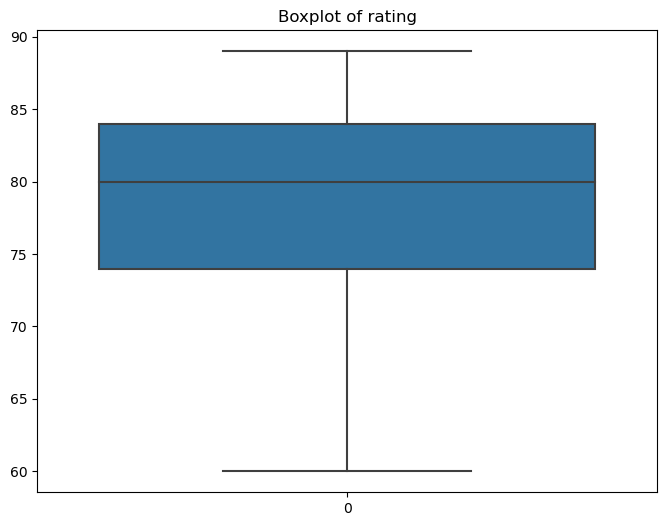

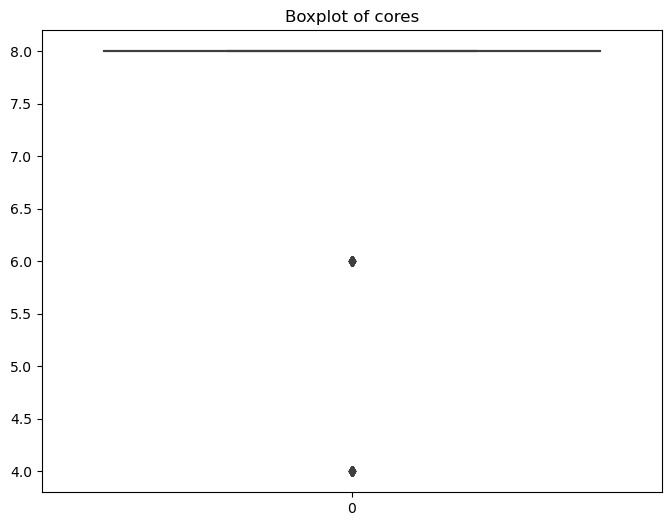

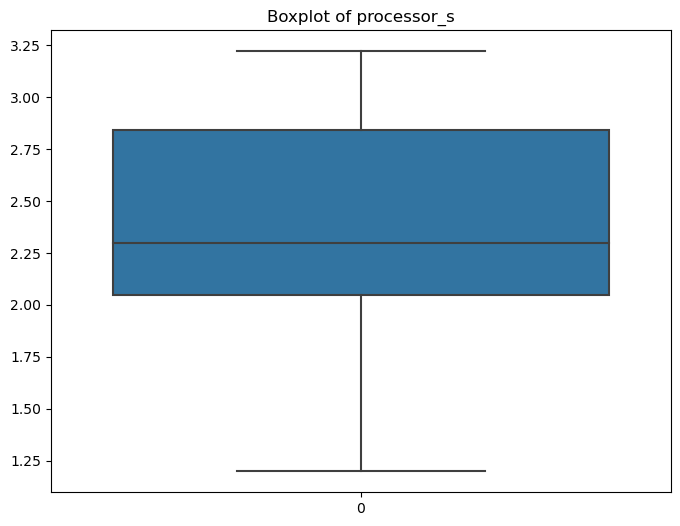

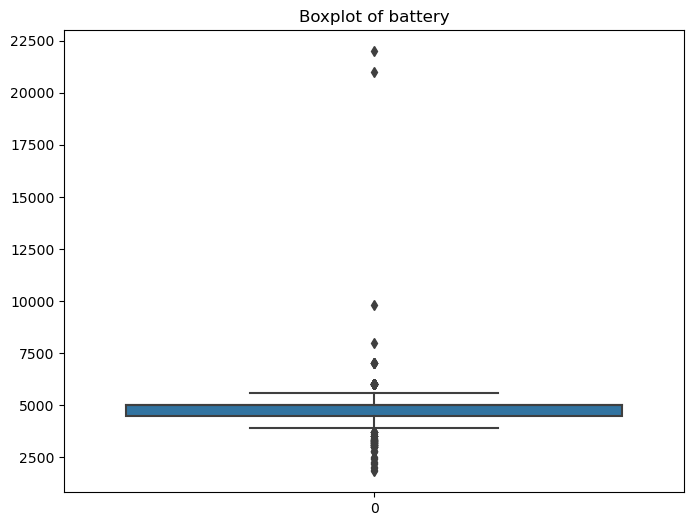

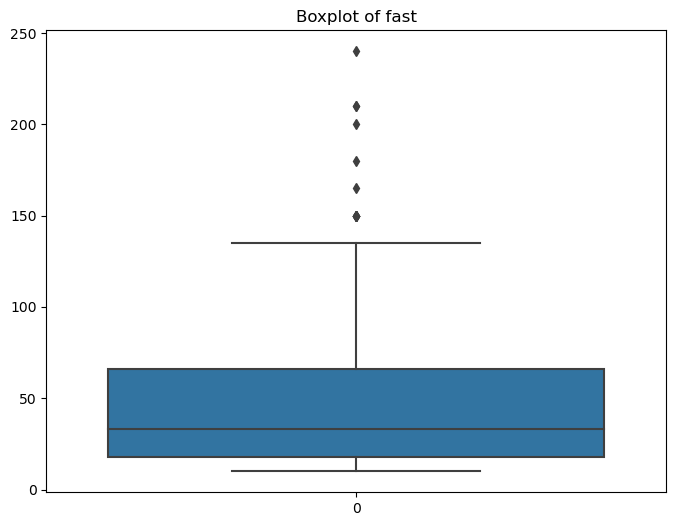

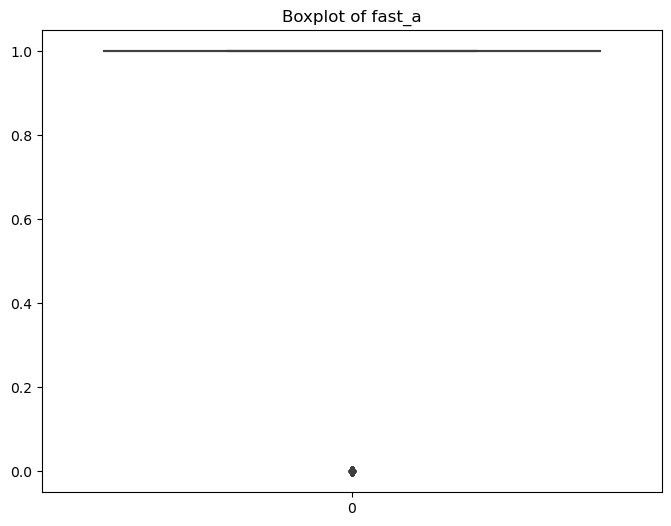

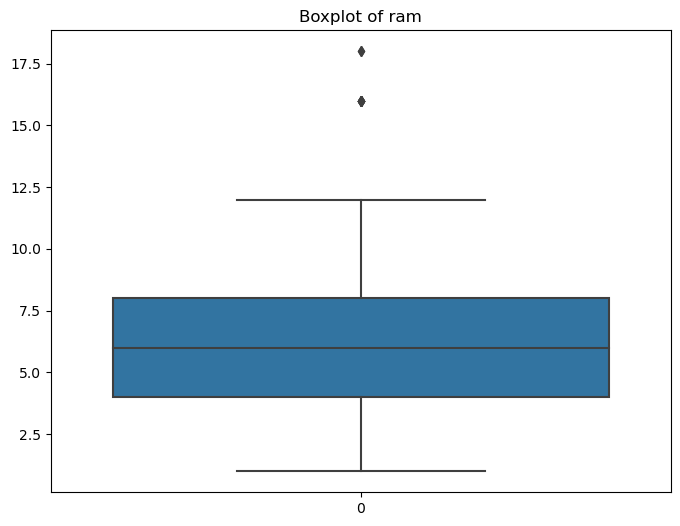

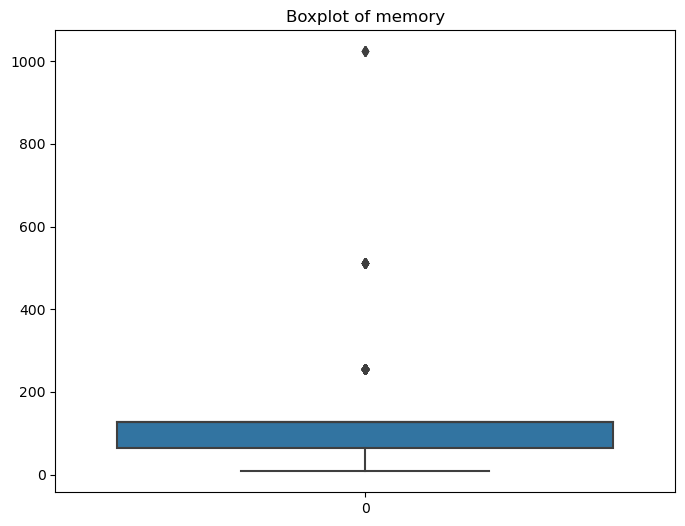

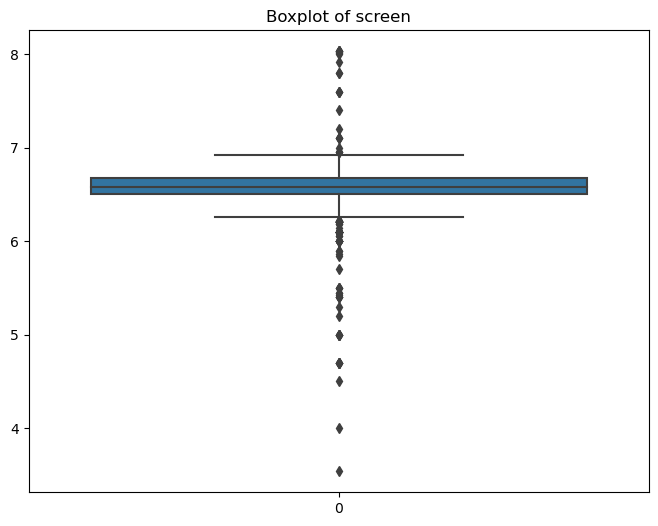

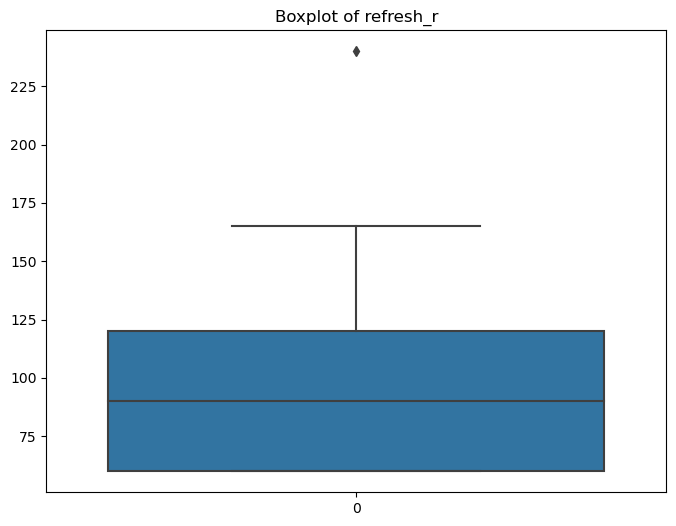

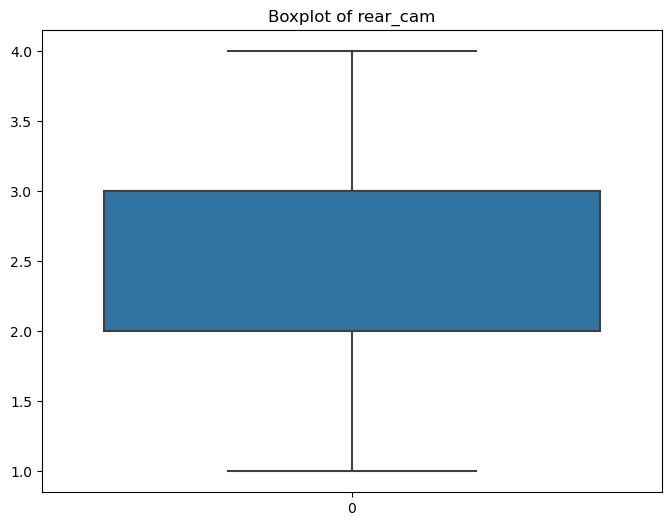

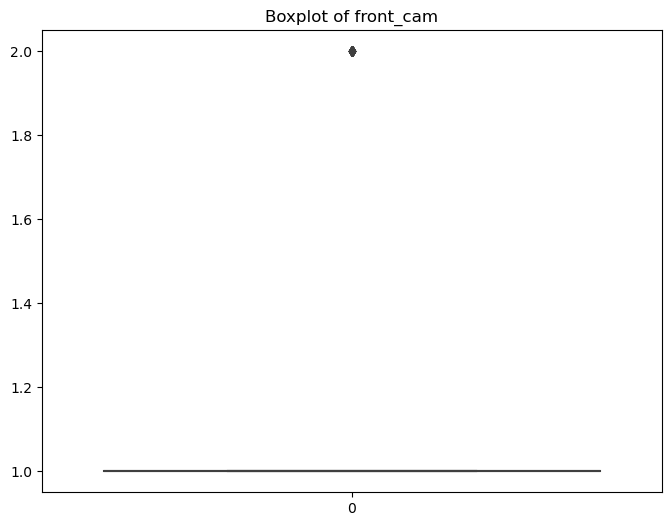

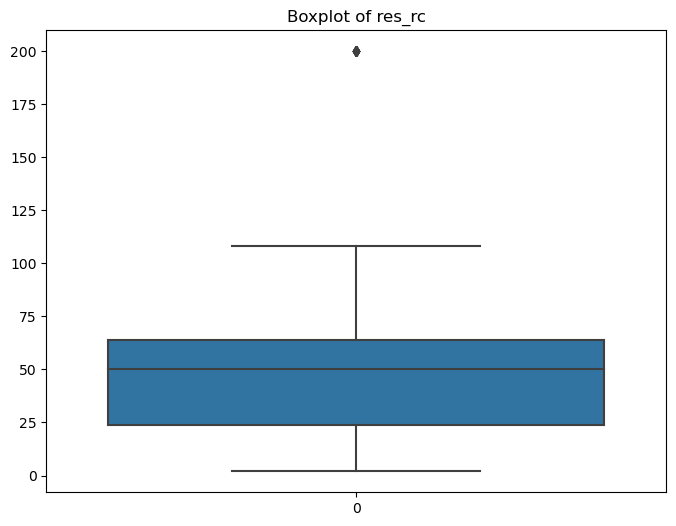

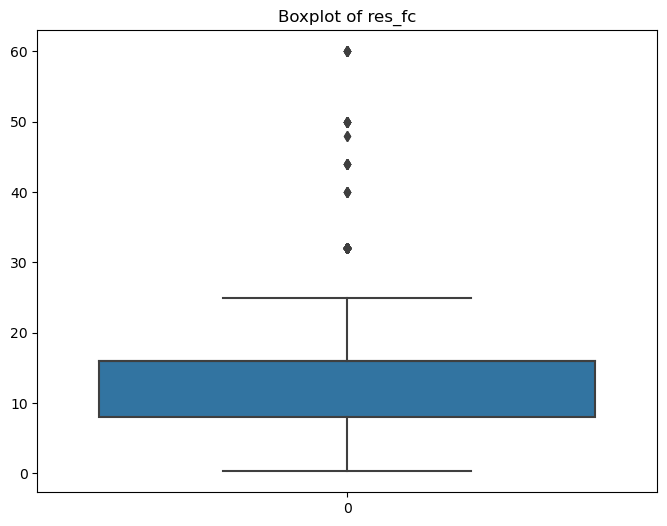

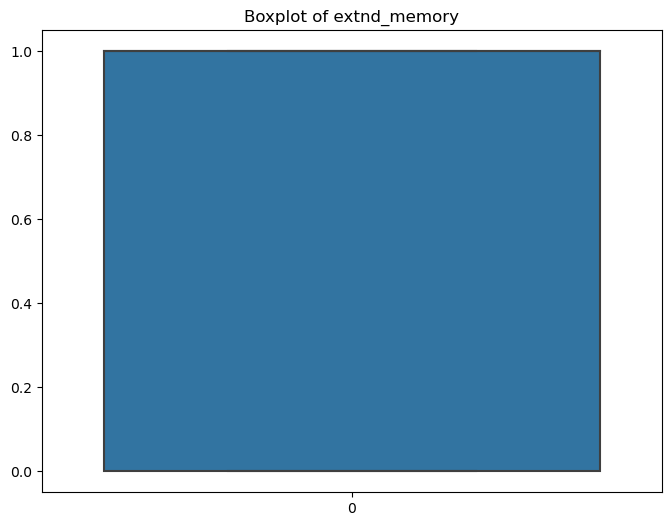

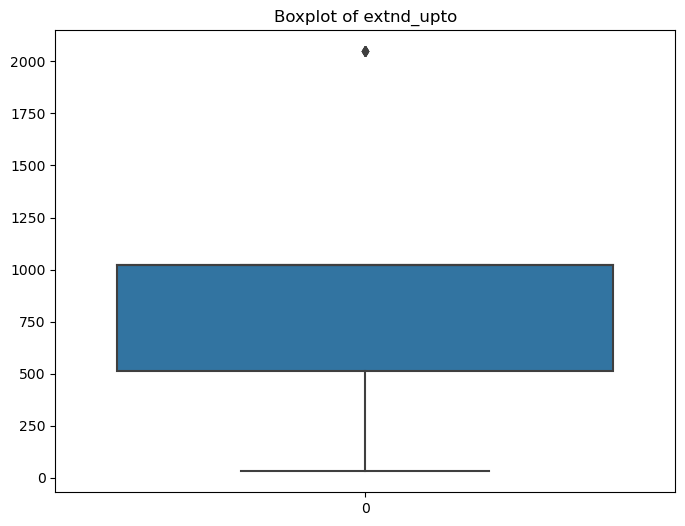

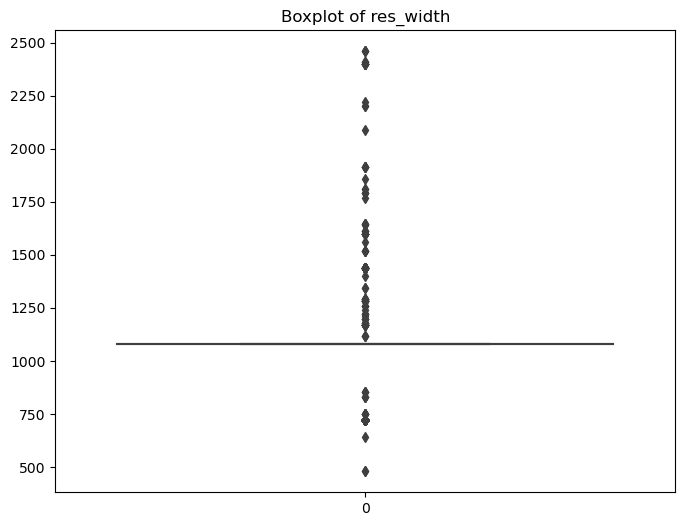

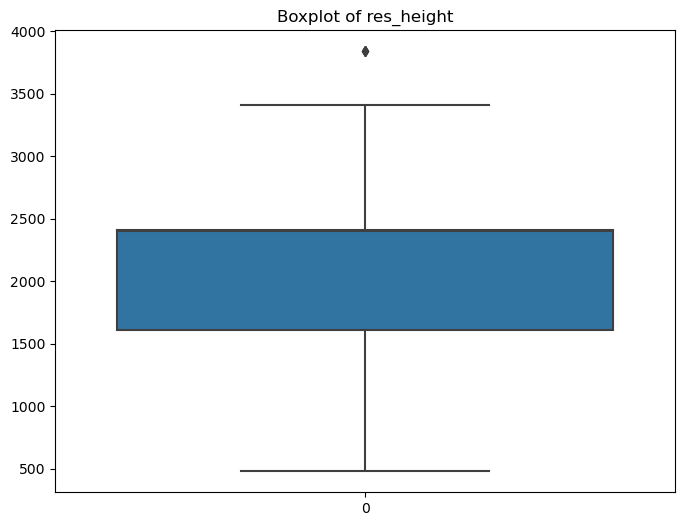

In [10]:
for column in numerical:
    
    plt.figure(figsize=(8,6))
    
    sns.boxplot(data= smartphones[column])
    
    plt.title("Boxplot of " +column)

In [11]:
smartphones_num.loc['null']= smartphones[numerical].isnull().sum()
smartphones_num.loc['%_missing'] = smartphones[numerical].isnull().sum()/980*100
smartphones_num.T

,count,mean,std,min,25%,50%,75%,max,null,%_missing
rating,879.0,78.258248,7.402854,60.00,74.00,80.00,84.00,89.00,101.0,10.306122
cores,974.0,7.772074,0.836845,4.00,8.00,8.00,8.00,8.00,6.0,0.612245
processor_s,938.0,2.427217,0.464090,1.20,2.05,2.30,2.84,3.22,42.0,4.285714
battery,969.0,4817.748194,1009.540054,1821.00,4500.00,5000.00,5000.00,22000.00,11.0,1.122449
fast,769.0,46.126138,34.277870,10.00,18.00,33.00,66.00,240.00,211.0,21.530612
fast_a,980.0,0.854082,0.353205,0.00,1.00,1.00,1.00,1.00,0.0,0.000000
ram,980.0,6.560204,2.744378,1.00,4.00,6.00,8.00,18.00,0.0,0.000000
memory,980.0,141.036735,107.134516,8.00,64.00,128.00,128.00,1024.00,0.0,0.000000
screen,980.0,6.536765,0.349162,3.54,6.50,6.58,6.67,8.03,0.0,0.000000
refresh_r,980.0,92.256122,28.988052,60.00,60.00,90.00,120.00,240.00,0.0,0.000000


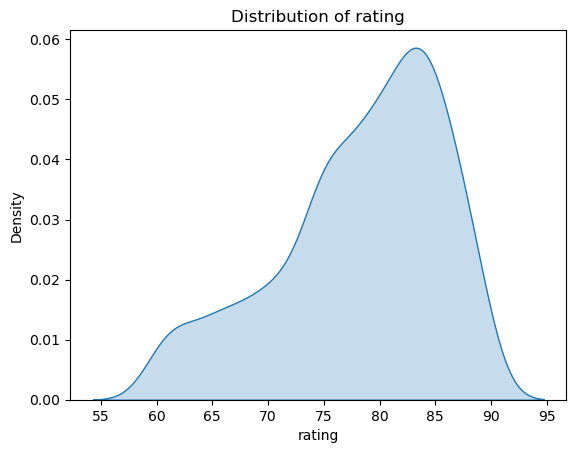

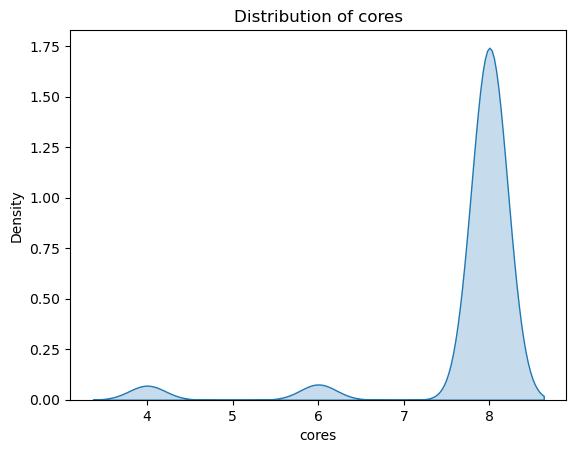

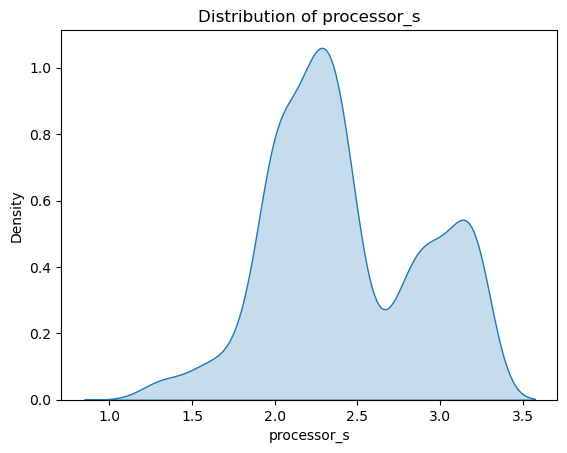

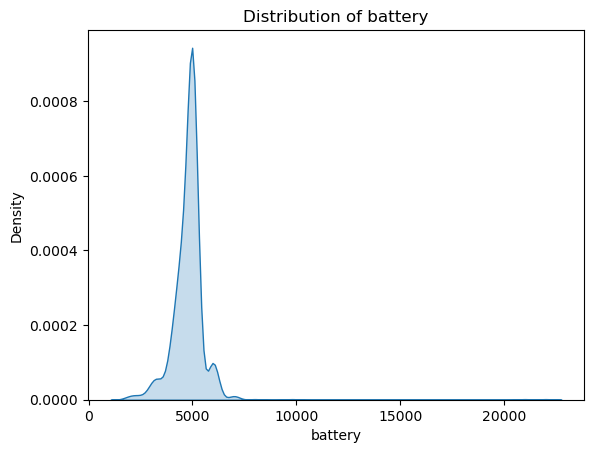

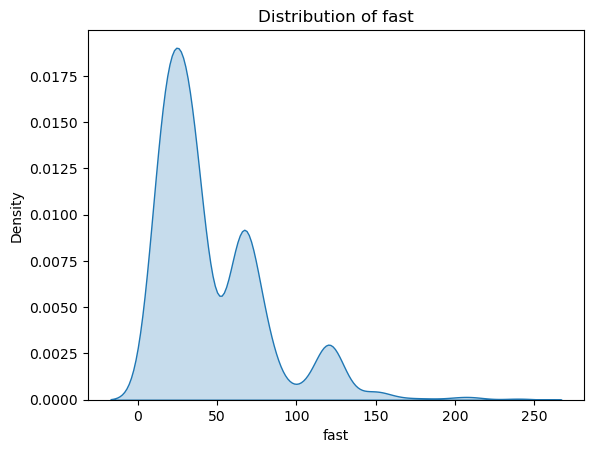

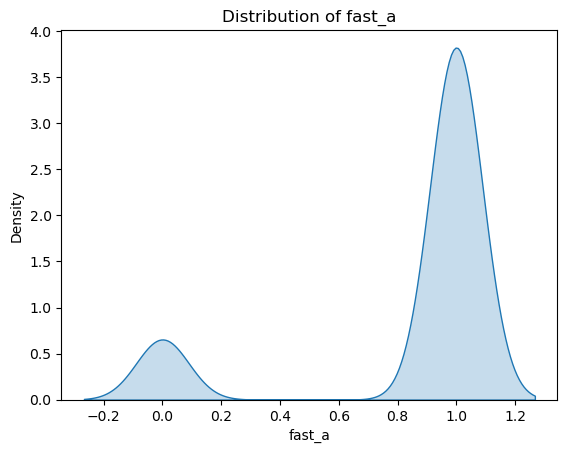

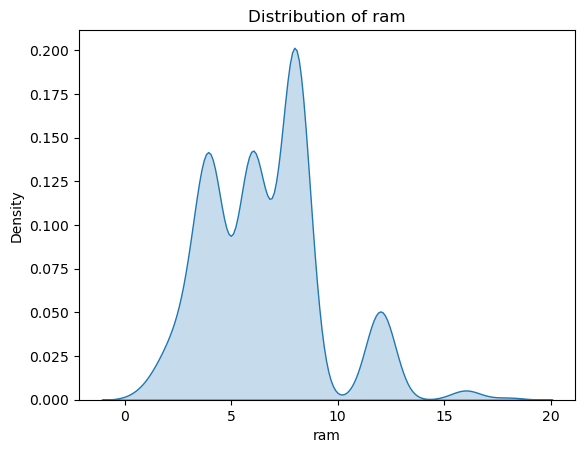

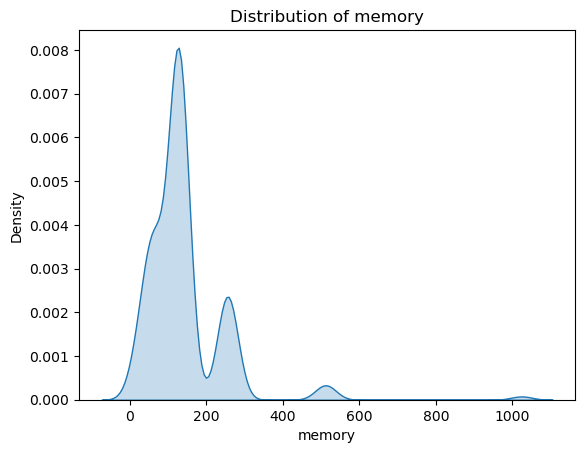

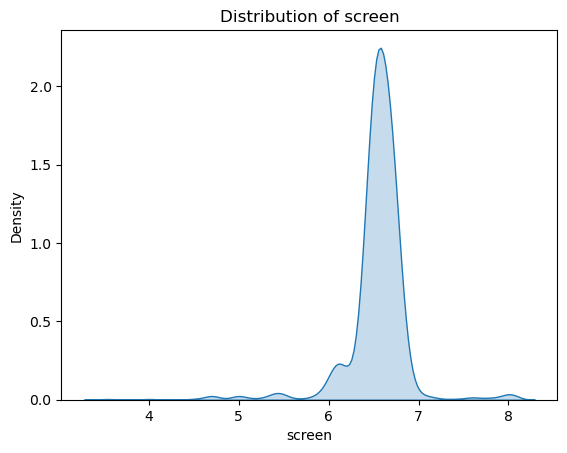

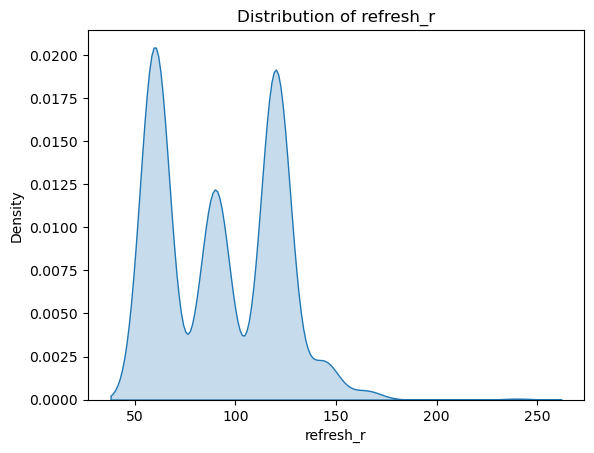

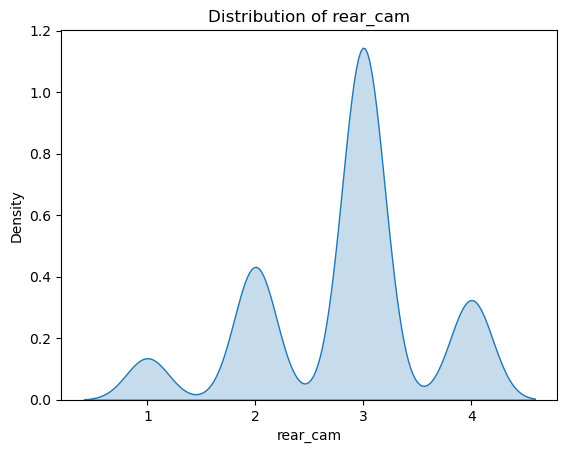

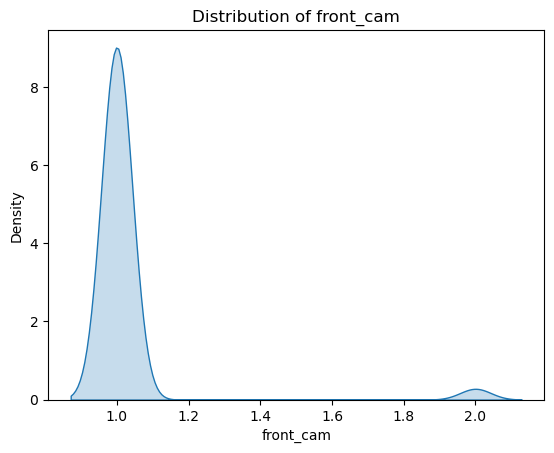

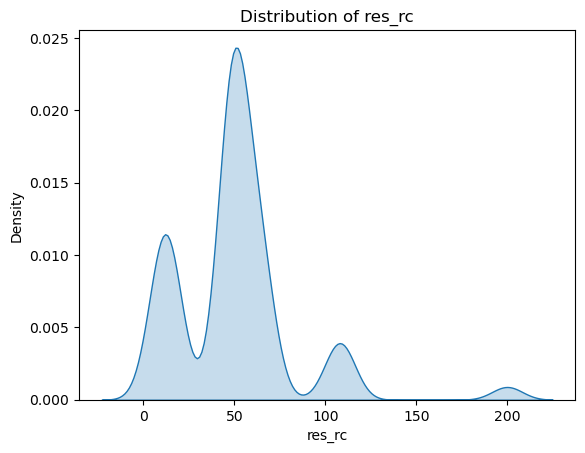

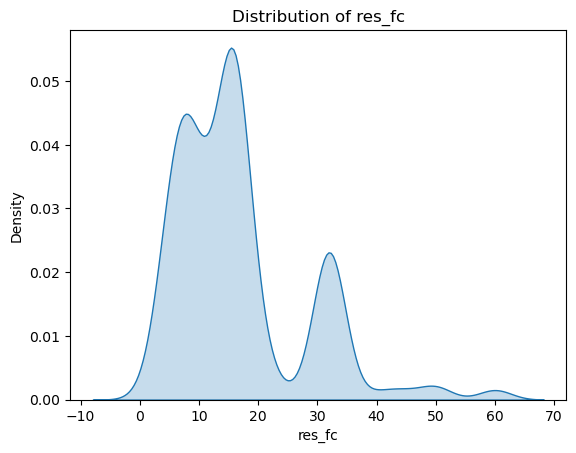

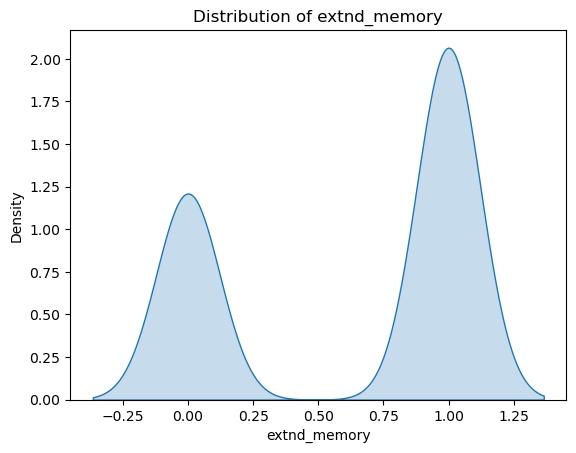

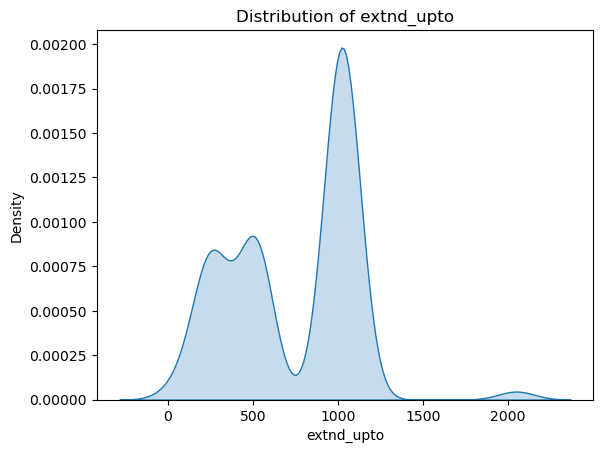

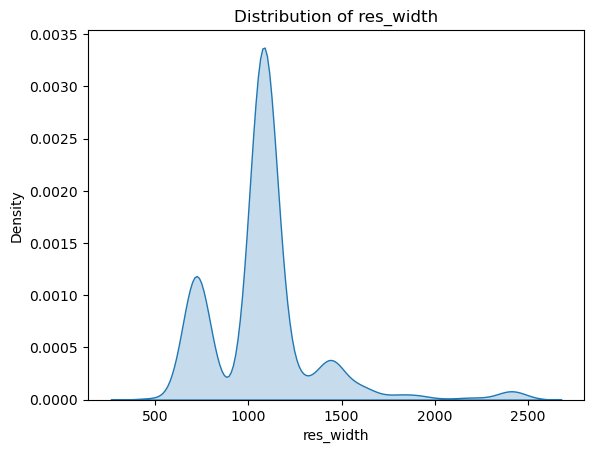

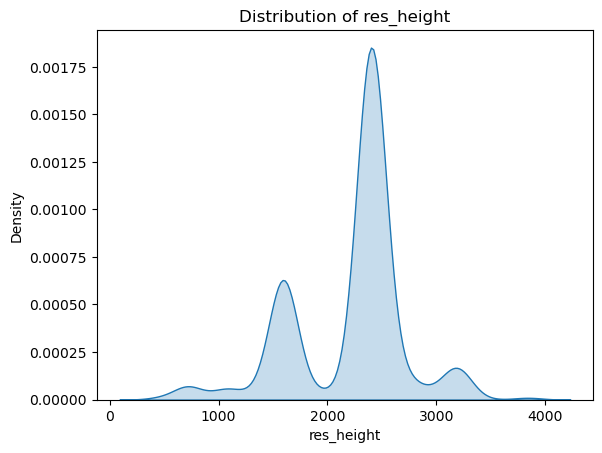

In [12]:
for column in numerical:
    
    plt.figure()
    
    sns.kdeplot(data=smartphones[column], fill=True)
    
    
    plt.title("Distribution of " +column)

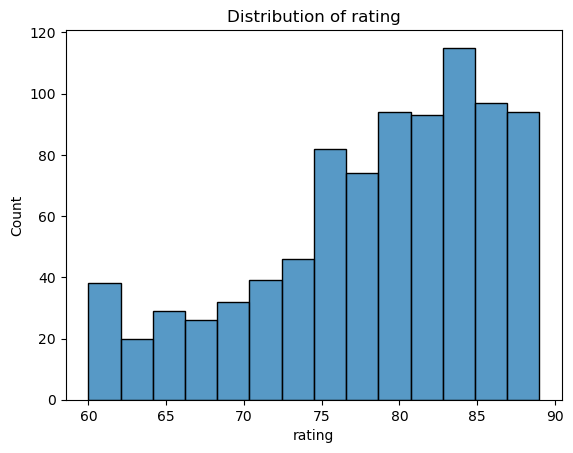

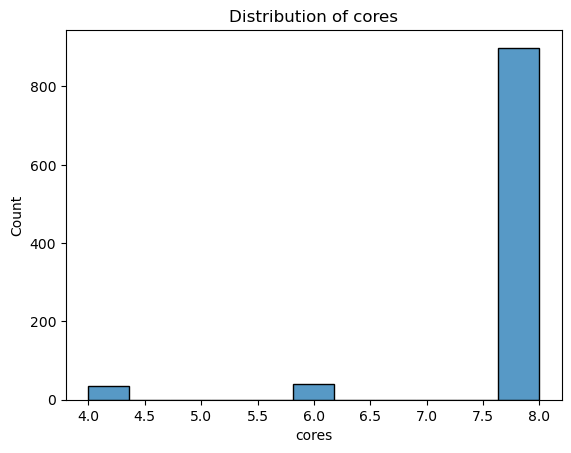

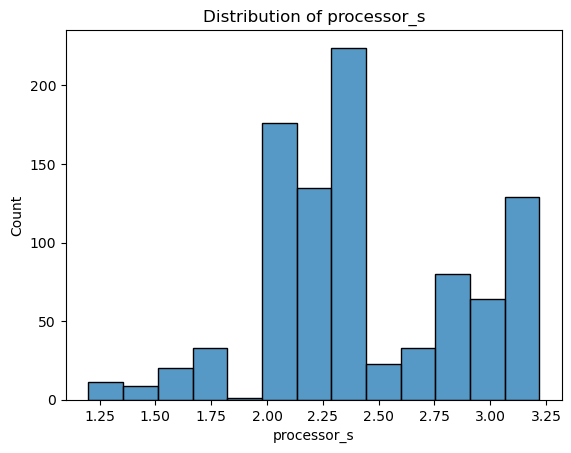

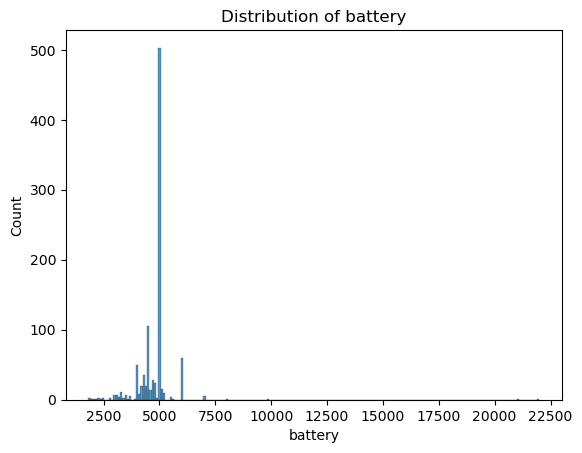

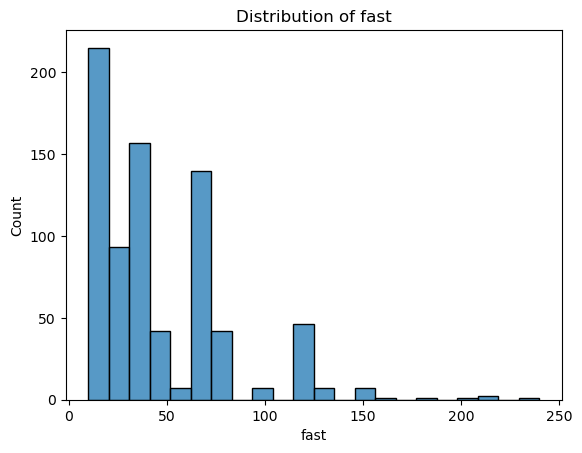

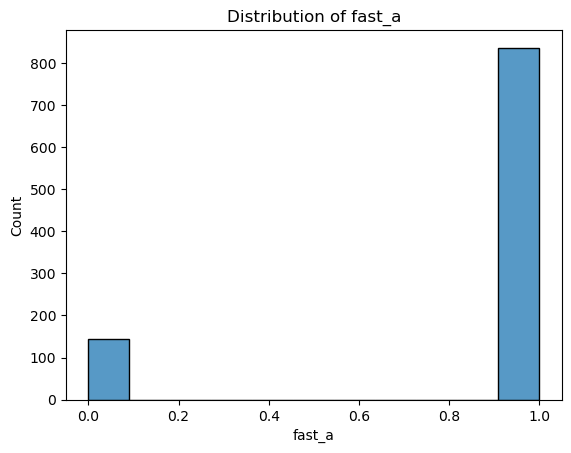

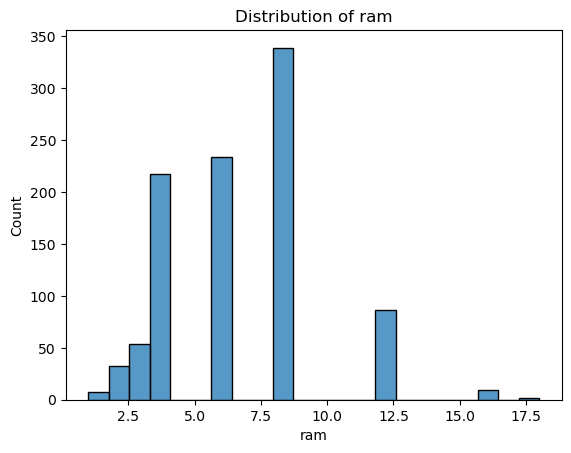

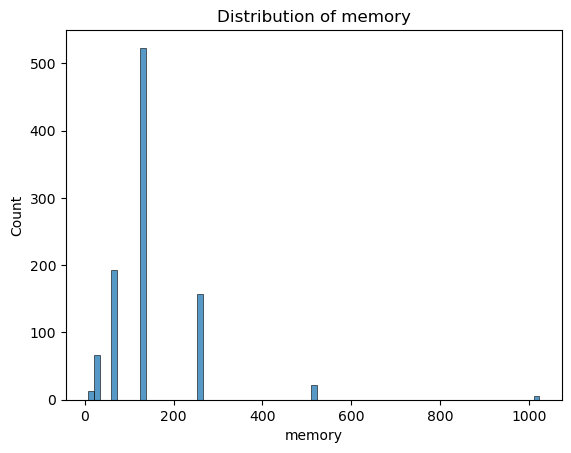

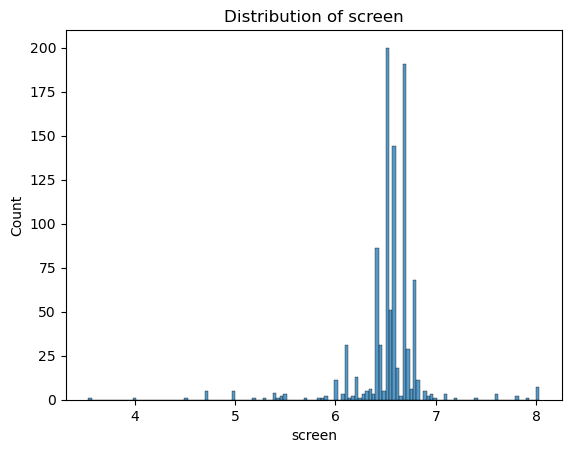

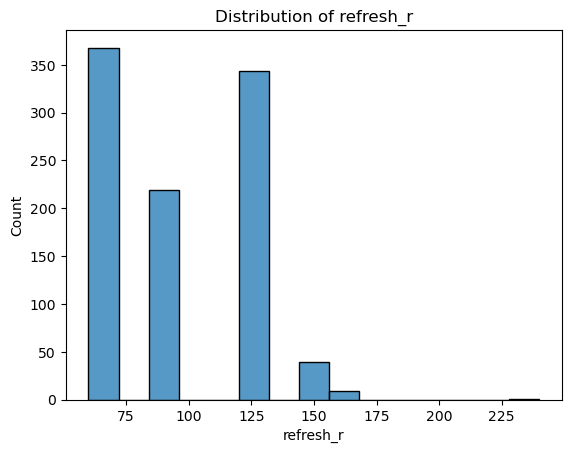

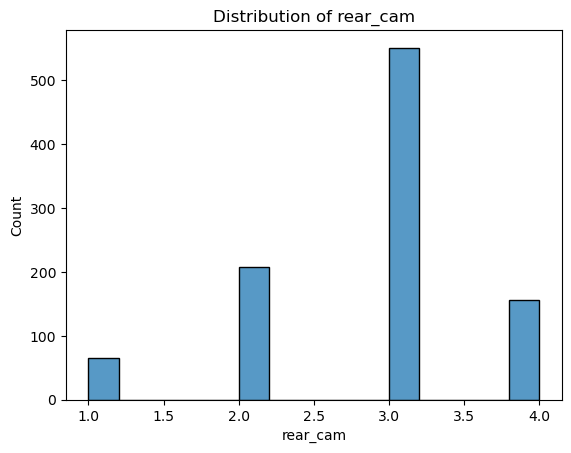

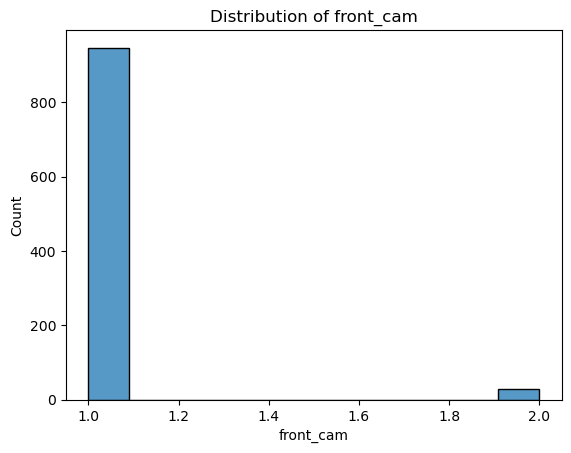

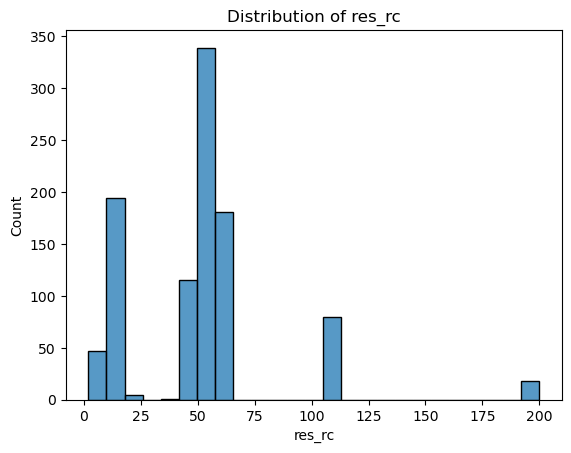

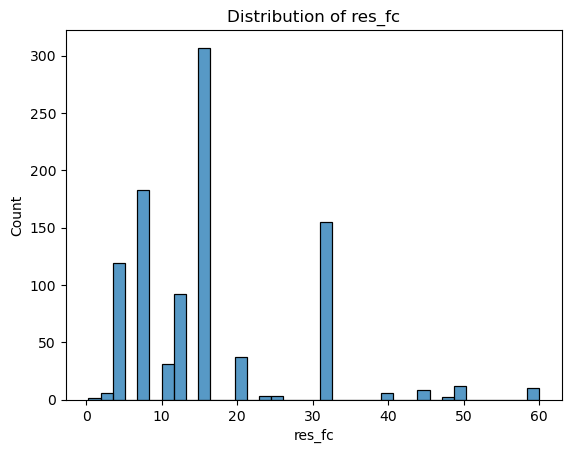

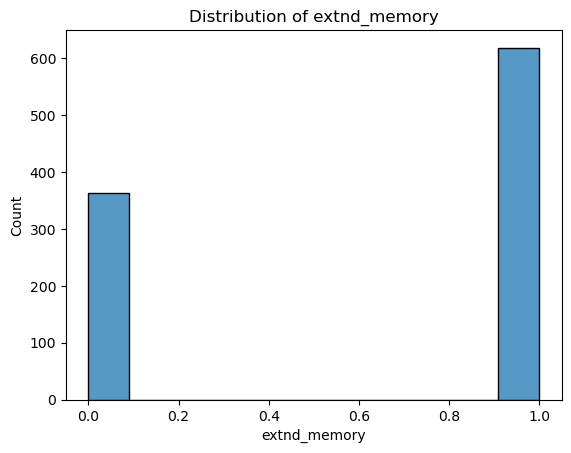

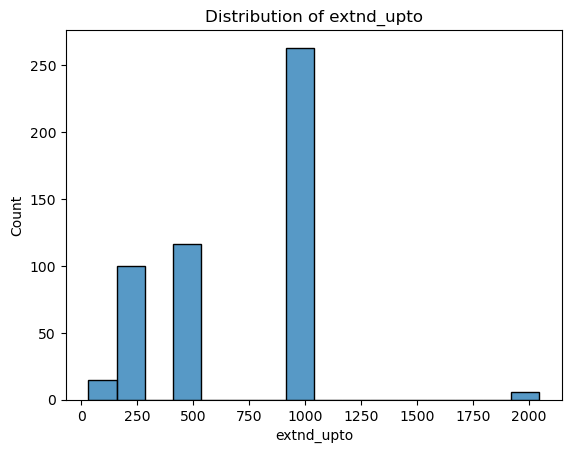

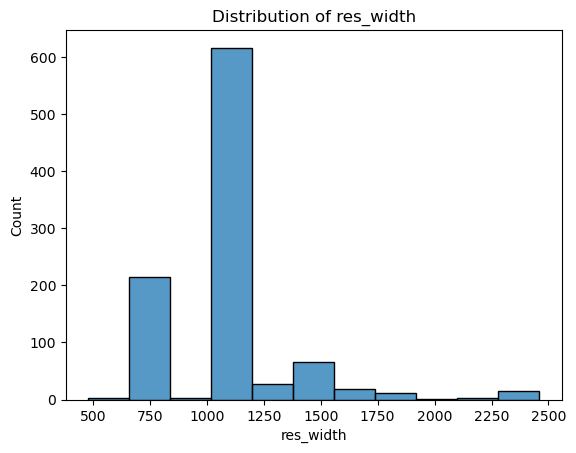

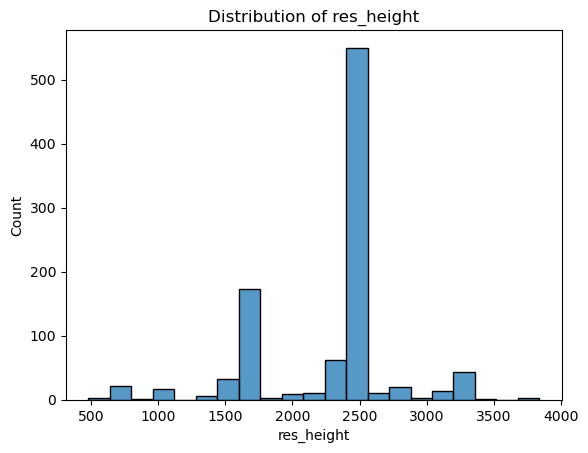

In [13]:
for column in numerical:
    
    plt.figure()
    
    sns.histplot(data=smartphones[column], fill=True)
    
    
    plt.title("Distribution of " +column)

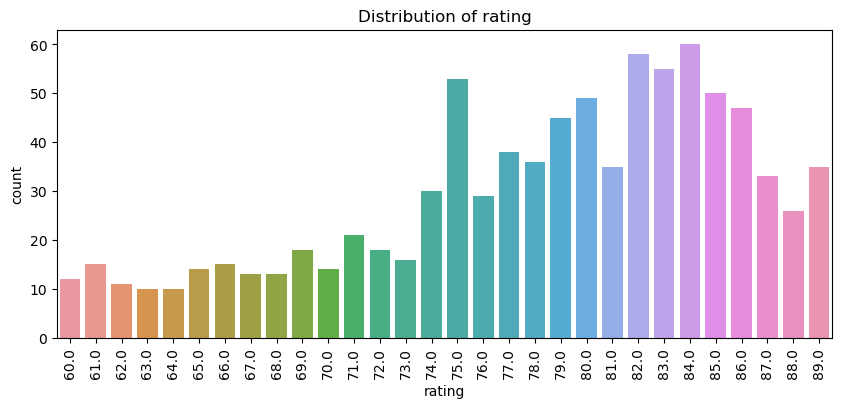

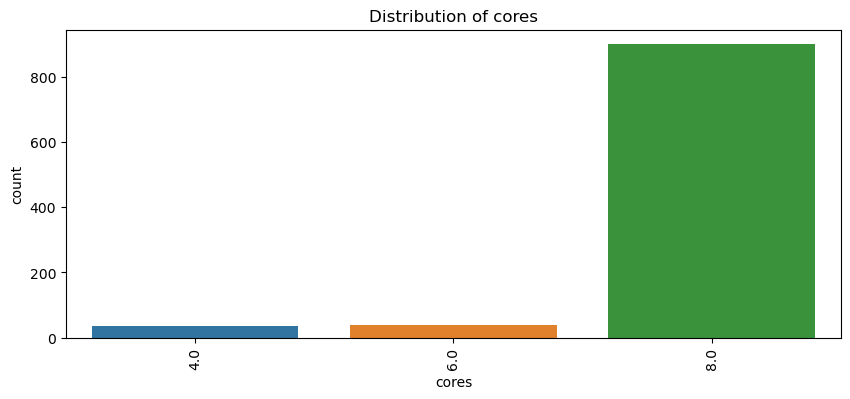

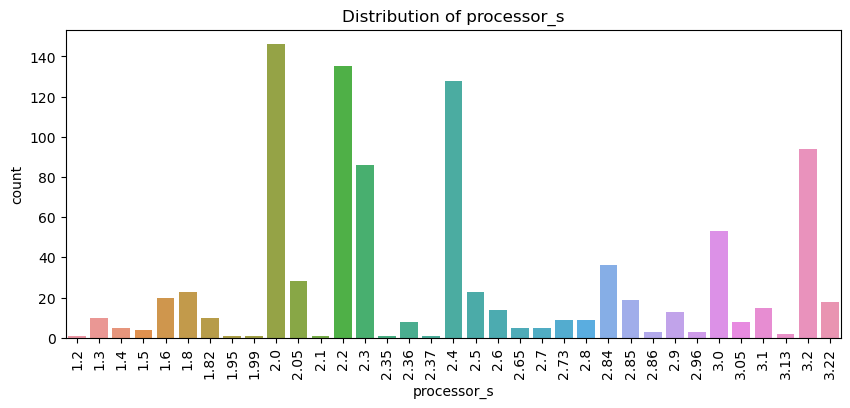

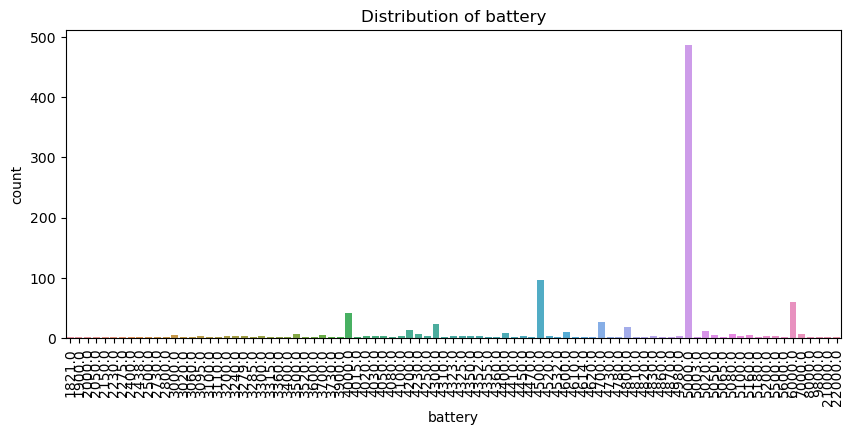

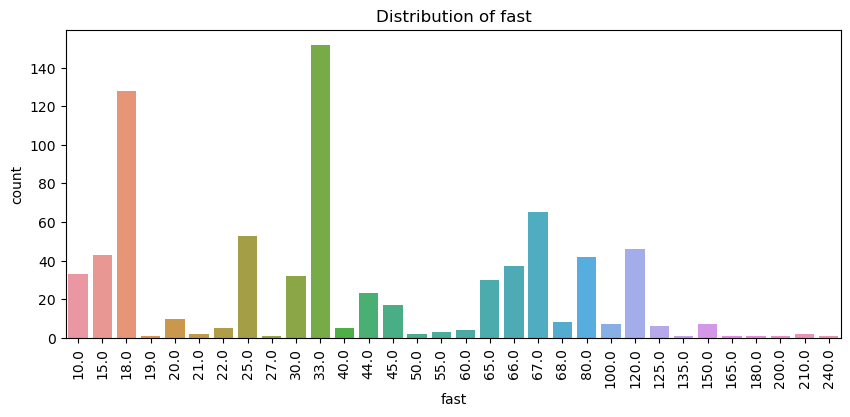

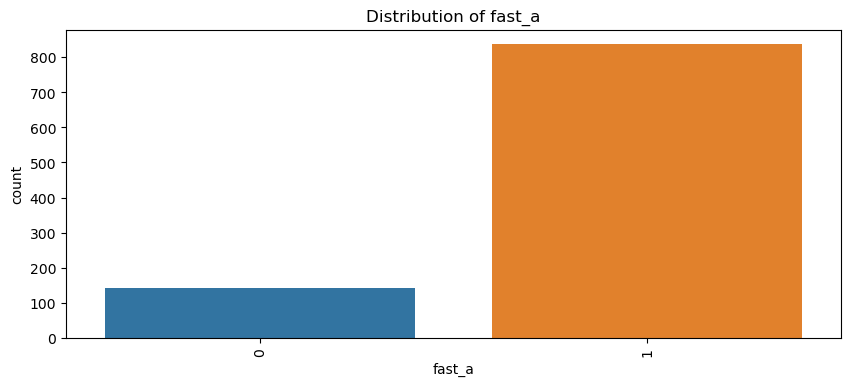

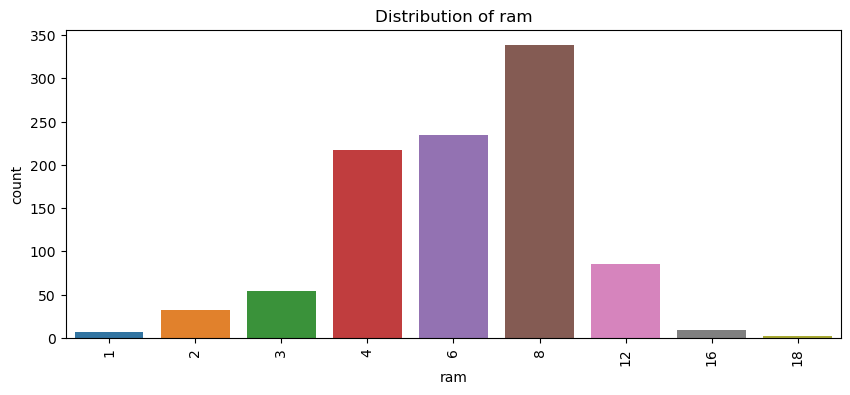

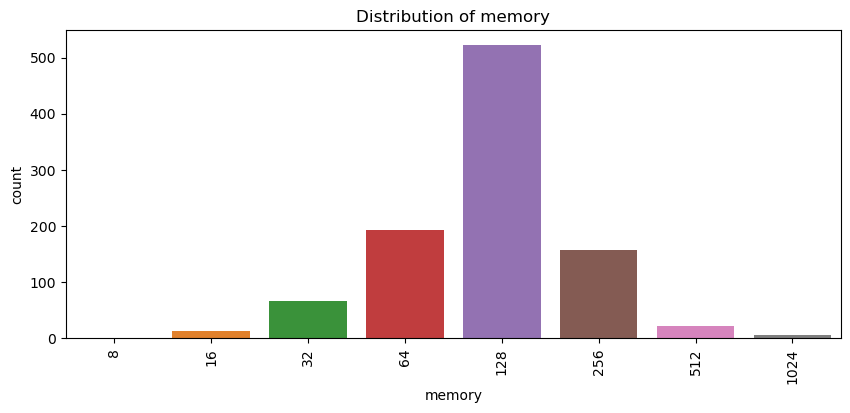

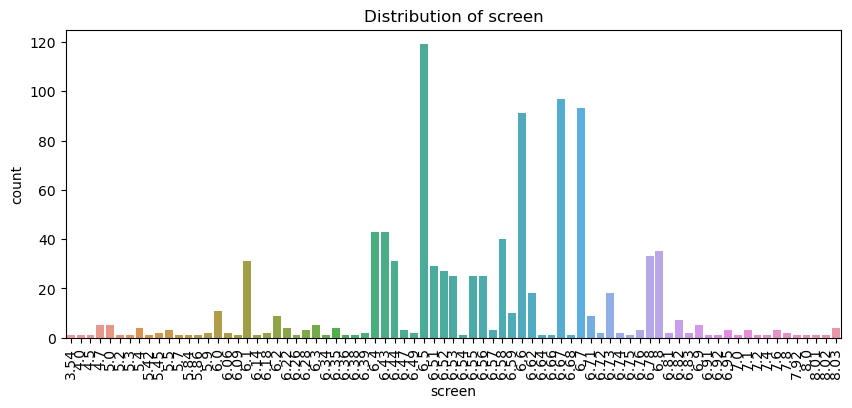

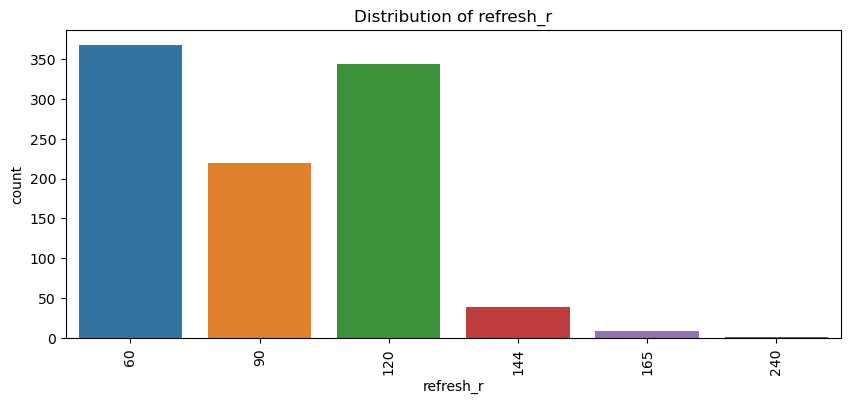

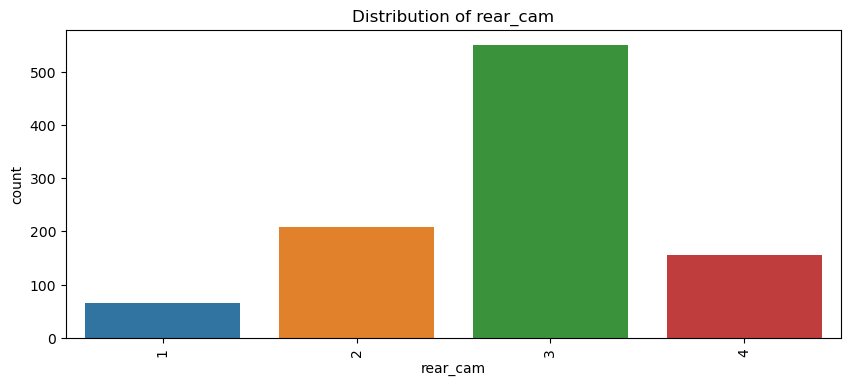

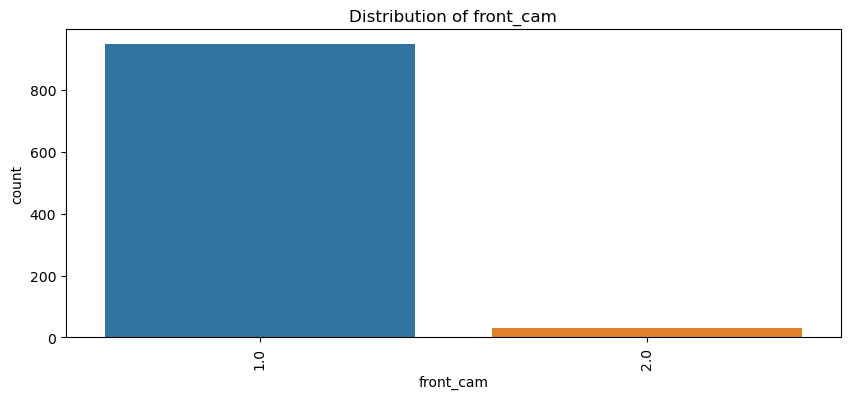

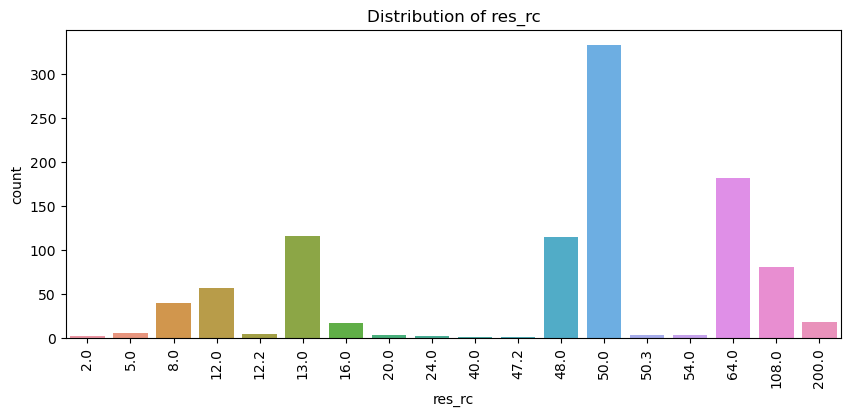

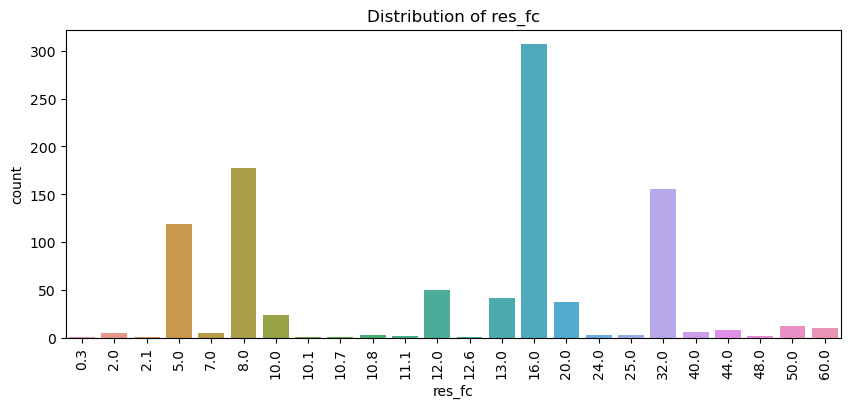

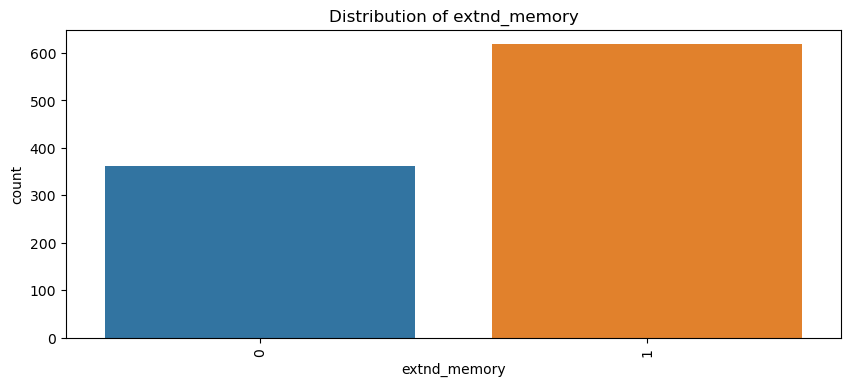

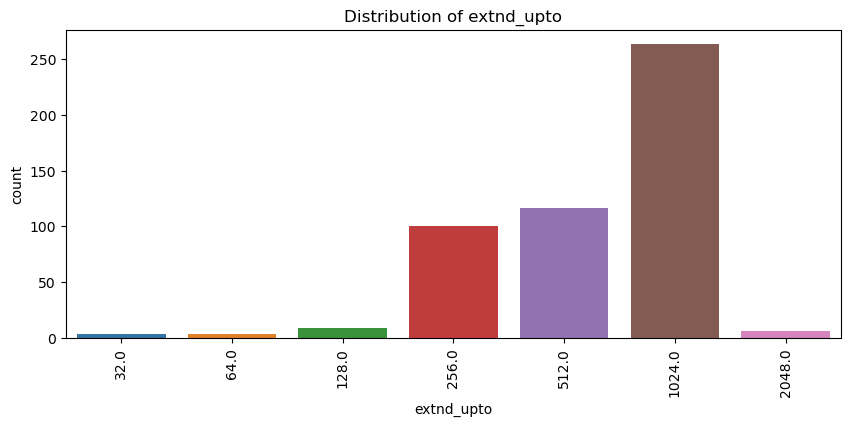

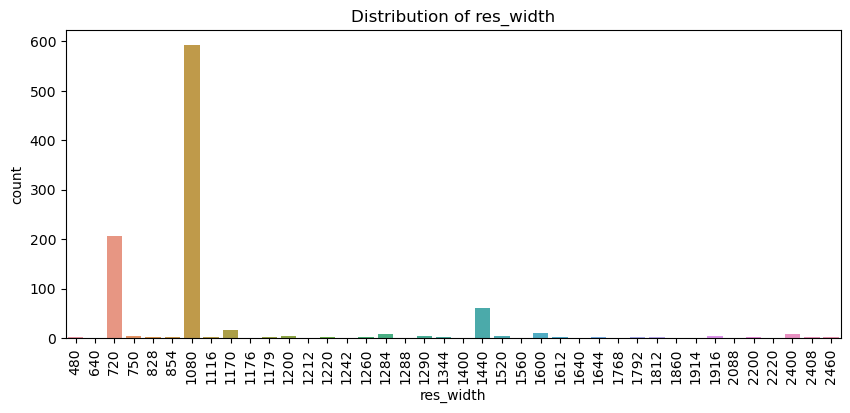

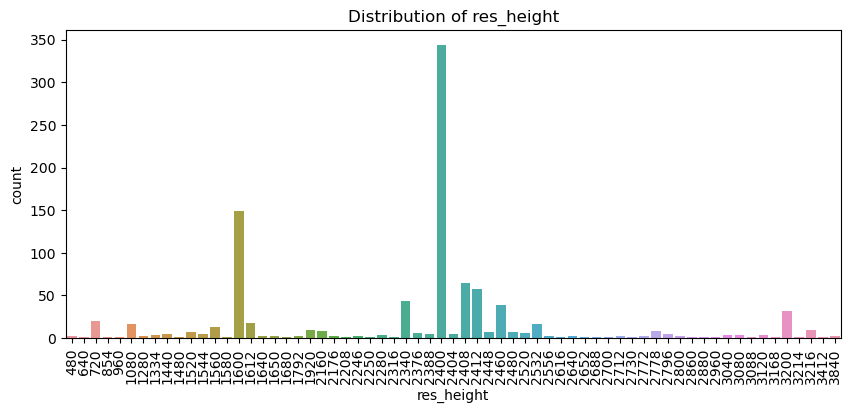

In [14]:
for column in numerical:
    #make sure that plot only takes the two plots below by using the following command
    plt.figure(figsize=(10,4))
    plt.xticks(rotation=90) 
    # produce a plot for each incomelabel so they interlink
    sns.countplot(x=column, data=smartphones)
  
    #include a dynamic title
    plt.title("Distribution of " +column)

## Categorical variables

In [15]:
smartphones[categorical].head()

,brand,model,5g,nfc,ir_blst,processor_b,os
0,oneplus,OnePlus 11 5G,True,True,False,snapdragon,android
1,oneplus,OnePlus Nord CE 2 Lite 5G,True,False,False,snapdragon,android
2,samsung,Samsung Galaxy A14 5G,True,False,False,exynos,android
3,motorola,Motorola Moto G62 5G,True,False,False,snapdragon,android
4,realme,Realme 10 Pro Plus,True,False,False,dimensity,android


In [16]:
smartphones[categorical].describe()

,brand,model,5g,nfc,ir_blst,processor_b,os
count,980,980,980,980,980,960,966
unique,46,980,2,2,2,13,3
top,xiaomi,OnePlus 11 5G,True,False,False,snapdragon,android
freq,134,1,549,587,821,413,909


In [17]:
smartphones_cat = smartphones[categorical].describe()
smartphones_cat.loc['null']= smartphones[categorical].isnull().sum()
smartphones_cat

,brand,model,5g,nfc,ir_blst,processor_b,os
count,980,980,980,980,980,960,966
unique,46,980,2,2,2,13,3
top,xiaomi,OnePlus 11 5G,True,False,False,snapdragon,android
freq,134,1,549,587,821,413,909
null,0,0,0,0,0,20,14


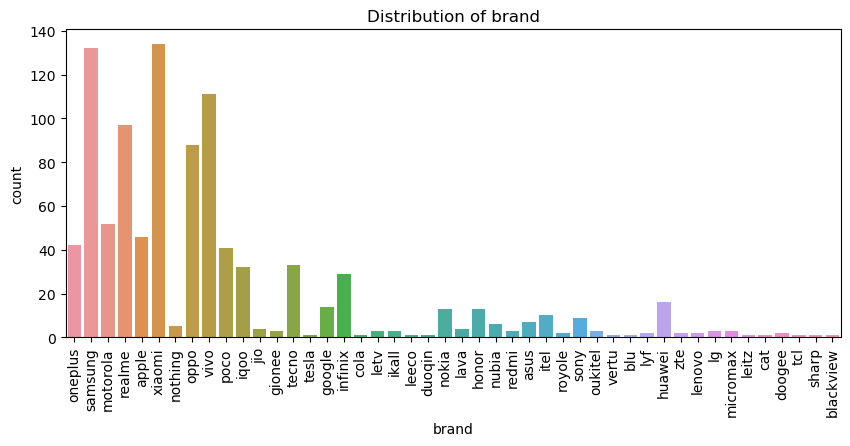

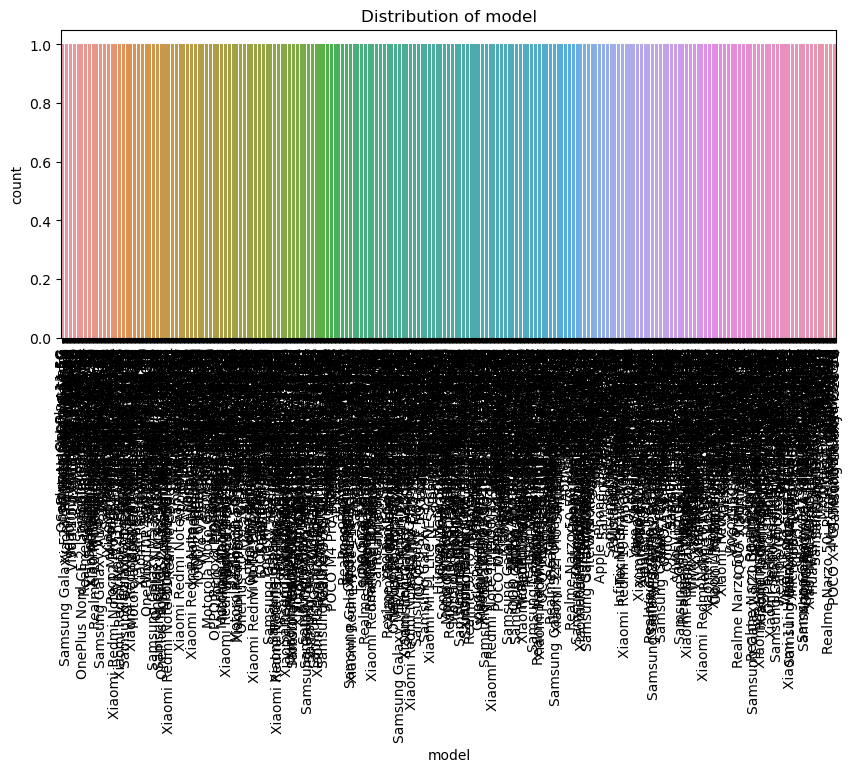

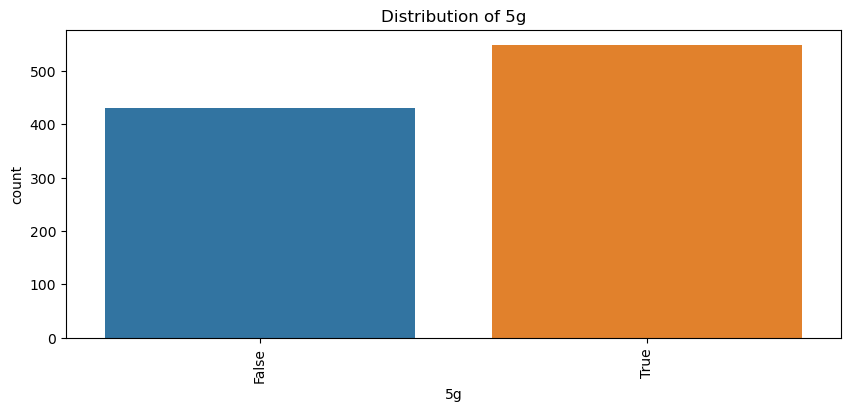

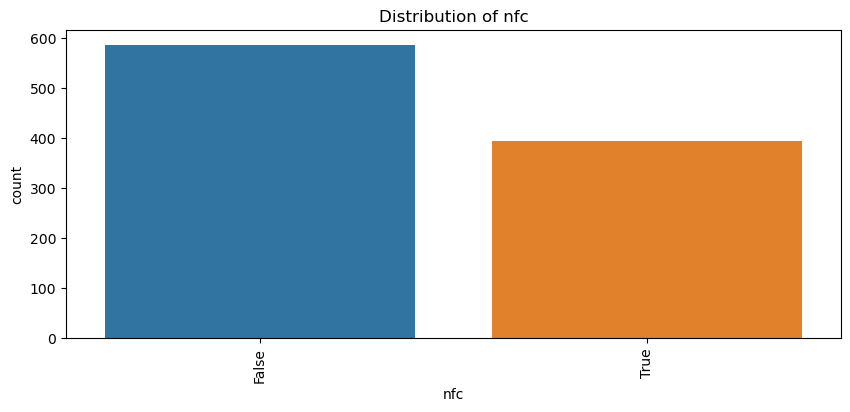

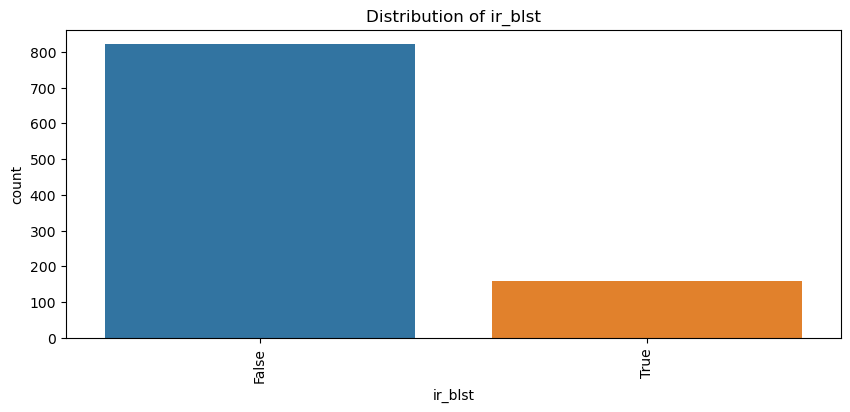

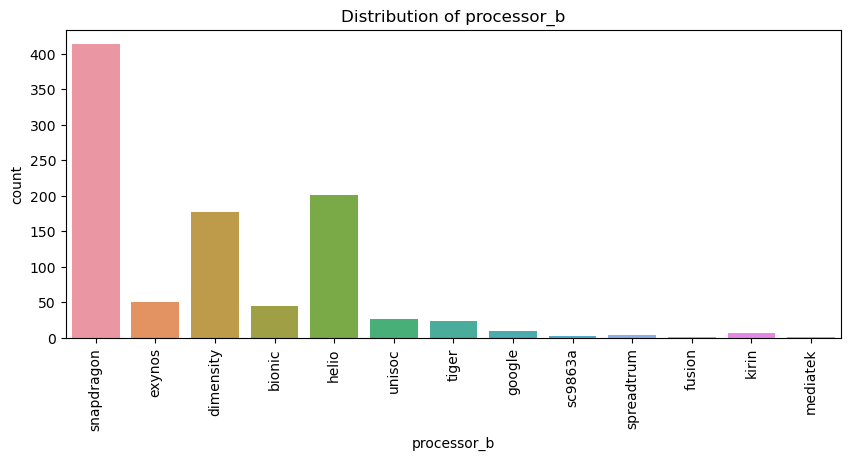

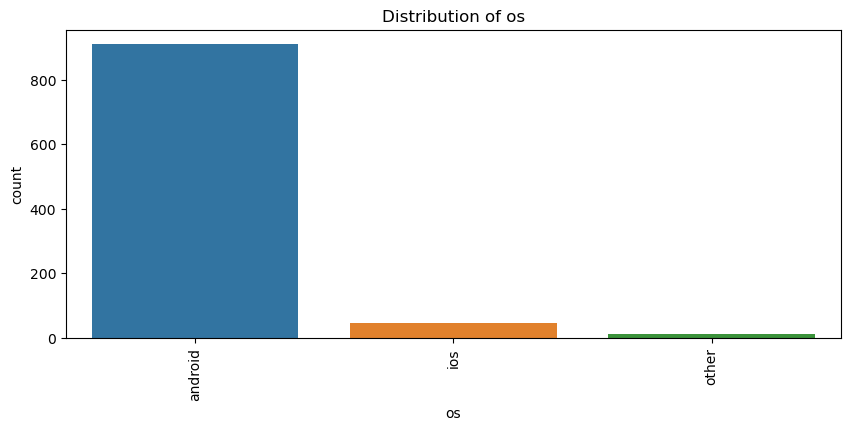

In [18]:
for column in categorical:
    #make sure that plot only takes the two plots below by using the following command
    plt.figure(figsize=(10,4))
    plt.xticks(rotation=90) 
    # produce a plot for each incomelabel so they interlink
    sns.countplot(x=column, data=smartphones)
  
    #include a dynamic title
    plt.title("Distribution of " +column)

In [19]:
smartphones.loc[smartphones.brand == 'apple']

,brand,model,price,price_GBP,rating,5g,nfc,ir_blst,processor_b,cores,...,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,extnd_upto,res_width,res_height
6,apple,Apple iPhone 14,65999,627,81.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1170,2532
15,apple,Apple iPhone 13,62999,598,79.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1170,2532
27,apple,Apple iPhone 14 Pro Max,129990,1235,76.0,True,True,False,bionic,6.0,...,120,3,1.0,ios,48.0,12.0,0,NaN,1290,2796
33,apple,Apple iPhone 11,38999,370,73.0,False,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,828,1792
56,apple,Apple iPhone 14 Plus,74999,712,82.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1284,2778
76,apple,Apple iPhone 13 Pro,119900,1139,83.0,True,True,False,bionic,6.0,...,120,3,1.0,ios,12.0,12.0,0,NaN,1170,2532
100,apple,Apple iPhone 14 Pro,119990,1140,75.0,True,True,False,bionic,6.0,...,120,3,1.0,ios,48.0,12.0,0,NaN,1179,2556
111,apple,Apple iPhone 12,51999,494,74.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1170,2532
136,apple,Apple iPhone 11 (128GB),46999,446,75.0,False,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,828,1792
149,apple,Apple iPhone 12 Mini,40999,389,74.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1080,2340


In [20]:
smartphones.loc[smartphones.os == 'other']

,brand,model,price,price_GBP,rating,5g,nfc,ir_blst,processor_b,cores,...,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,extnd_upto,res_width,res_height
69,oppo,Oppo Find N Fold,99990,950,NaN,True,True,False,snapdragon,8.0,...,120,2,NaN,other,50.0,NaN,0,NaN,1792,1920
75,gionee,Gionee G13 Pro,6190,59,NaN,False,False,False,tiger,4.0,...,60,2,1.0,other,13.0,5.0,1,NaN,720,1600
478,huawei,Huawei Mate 50 RS Porsche Design,239999,2280,81.0,False,True,True,snapdragon,8.0,...,120,3,1.0,other,50.0,13.0,1,256.0,1212,2616
631,huawei,Huawei Mate 40 Pro 4G,69990,665,NaN,False,True,True,kirin,8.0,...,90,3,2.0,other,50.0,13.0,1,256.0,1344,2772
702,huawei,Huawei Mate 50 Pro 5G,99990,950,85.0,True,True,False,kirin,8.0,...,120,3,1.0,other,64.0,13.0,0,NaN,1440,3200
712,huawei,Huawei Nova 9,29990,285,83.0,False,True,False,snapdragon,8.0,...,120,4,1.0,other,50.0,32.0,0,NaN,1080,2340
714,huawei,Huawei P50 Pro 4G,60999,579,NaN,False,True,True,snapdragon,8.0,...,120,4,1.0,other,50.0,13.0,1,256.0,1288,2700
844,huawei,Huawei Nova Y61,21990,209,63.0,False,False,False,NaN,8.0,...,60,3,1.0,other,50.0,5.0,1,NaN,720,1600
851,huawei,Huawei Nova 10,29990,285,82.0,False,False,False,snapdragon,8.0,...,120,3,1.0,other,50.0,60.0,0,NaN,1080,2400
852,huawei,Huawei Nova Y90,22990,218,82.0,False,True,False,snapdragon,8.0,...,90,4,1.0,other,50.0,8.0,1,NaN,1080,2388


In [21]:
smartphones.loc[smartphones.processor_b == 'bionic']

,brand,model,price,price_GBP,rating,5g,nfc,ir_blst,processor_b,cores,...,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,extnd_upto,res_width,res_height
6,apple,Apple iPhone 14,65999,627,81.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1170,2532
15,apple,Apple iPhone 13,62999,598,79.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1170,2532
27,apple,Apple iPhone 14 Pro Max,129990,1235,76.0,True,True,False,bionic,6.0,...,120,3,1.0,ios,48.0,12.0,0,NaN,1290,2796
33,apple,Apple iPhone 11,38999,370,73.0,False,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,828,1792
56,apple,Apple iPhone 14 Plus,74999,712,82.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1284,2778
76,apple,Apple iPhone 13 Pro,119900,1139,83.0,True,True,False,bionic,6.0,...,120,3,1.0,ios,12.0,12.0,0,NaN,1170,2532
100,apple,Apple iPhone 14 Pro,119990,1140,75.0,True,True,False,bionic,6.0,...,120,3,1.0,ios,48.0,12.0,0,NaN,1179,2556
111,apple,Apple iPhone 12,51999,494,74.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1170,2532
136,apple,Apple iPhone 11 (128GB),46999,446,75.0,False,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,828,1792
149,apple,Apple iPhone 12 Mini,40999,389,74.0,True,True,False,bionic,6.0,...,60,2,1.0,ios,12.0,12.0,0,NaN,1080,2340


In [22]:
smartphones.loc[smartphones['os'].isna()]

,brand,model,price,price_GBP,rating,5g,nfc,ir_blst,processor_b,cores,...,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,extnd_upto,res_width,res_height
158,oppo,Oppo Find N2 5G,94990,902,NaN,True,True,False,snapdragon,8.0,...,120,3,2.0,NaN,50.0,32.0,0,NaN,1792,1920
304,samsung,Samsung Galaxy Z Flip 3,69999,665,84.0,True,True,False,snapdragon,8.0,...,120,2,1.0,NaN,12.0,10.0,0,NaN,1080,2640
320,royole,Royole FlexPai 2,109999,1045,87.0,True,False,False,snapdragon,8.0,...,60,3,1.0,NaN,64.0,32.0,0,NaN,1440,1920
363,oppo,OPPO Find N Flip,89990,855,88.0,True,True,False,dimensity,8.0,...,120,2,1.0,NaN,50.0,32.0,0,NaN,1200,2400
389,oppo,OPPO Find N2 Flip,70990,674,88.0,True,True,False,dimensity,8.0,...,120,2,1.0,NaN,50.0,32.0,0,NaN,1080,2520
498,samsung,Samsung Galaxy Z Flip 4 5G,89999,855,88.0,True,True,False,snapdragon,8.0,...,120,2,1.0,NaN,12.0,10.0,0,NaN,1080,2640
561,lg,LG Wing 5G,54999,522,89.0,True,True,False,snapdragon,8.0,...,60,3,1.0,NaN,64.0,32.0,0,NaN,1080,2460
599,oukitel,Oukitel WP21,22990,218,82.0,False,False,False,helio,8.0,...,120,3,1.0,NaN,64.0,NaN,0,NaN,1080,2400
662,lg,LG V60 ThinQ,79990,760,NaN,True,True,False,snapdragon,8.0,...,60,3,1.0,NaN,64.0,10.0,0,NaN,1080,2460
699,asus,Asus ROG Phone 6D Ultimate,107990,1026,NaN,True,True,False,dimensity,8.0,...,165,3,1.0,NaN,50.0,12.0,0,NaN,1080,2448


In [23]:
smartphones.loc[smartphones['front_cam'] != 1]

,brand,model,price,price_GBP,rating,5g,nfc,ir_blst,processor_b,cores,...,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,extnd_upto,res_width,res_height
69,oppo,Oppo Find N Fold,99990,950,NaN,True,True,False,snapdragon,8.0,...,120,2,NaN,other,50.0,NaN,0,NaN,1792,1920
71,vivo,Vivo V23 5G (12GB RAM + 256GB),27994,266,86.0,True,False,False,dimensity,8.0,...,90,3,2.0,android,64.0,50.0,1,NaN,1080,2400
125,vivo,Vivo V23 5G,24994,237,83.0,True,False,False,dimensity,8.0,...,90,3,2.0,android,64.0,50.0,0,NaN,1080,2400
158,oppo,Oppo Find N2 5G,94990,902,NaN,True,True,False,snapdragon,8.0,...,120,3,2.0,NaN,50.0,32.0,0,NaN,1792,1920
217,vivo,Vivo V23 Pro 5G,31994,304,85.0,True,False,False,dimensity,8.0,...,90,3,2.0,android,108.0,50.0,0,NaN,1080,2376
314,vivo,Vivo Y100,29990,285,82.0,True,False,False,dimensity,8.0,...,120,3,2.0,android,50.0,50.0,0,NaN,1080,2400
319,samsung,Samsung Galaxy Z Fold 4,154998,1472,NaN,True,True,False,snapdragon,8.0,...,120,3,2.0,android,50.0,10.0,0,NaN,1812,2176
369,vivo,Vivo V21 Pro,32999,313,85.0,True,False,False,snapdragon,8.0,...,60,4,2.0,android,64.0,44.0,0,NaN,1080,2400
372,google,Google Pixel 4,20120,191,78.0,False,True,False,snapdragon,8.0,...,60,2,2.0,android,16.0,8.0,0,NaN,1080,2280
373,samsung,Samsung Galaxy S10 Plus,42999,408,81.0,False,True,False,exynos,8.0,...,60,3,2.0,android,16.0,10.0,1,512.0,1440,3040


In [24]:
smartphones.os.value_counts()

android    909
ios         46
other       11
Name: os, dtype: int64

## 2. Data Cleansing and Pre-processing:
Undertake any cleansing or pre-processing you think is necessary on the dataset.
In your report, explain clearly what you have done and why you have done it. Some cleaning could be to remove any feature/column if 60% values are missing, constant, or to remove duplicate and highly correlated information.

In [25]:
smartphones.shape

(980, 27)

In [26]:
smartphones.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price,54999,19989,16499,14999,24999
price_GBP,522,190,157,142,237
rating,89.0,81.0,75.0,81.0,82.0
5g,True,True,True,True,True
nfc,True,False,False,False,False
ir_blst,False,False,False,False,False
processor_b,snapdragon,snapdragon,exynos,snapdragon,dimensity
cores,8.0,8.0,8.0,8.0,8.0


## Drop of columns

In [27]:
smartphones = smartphones.drop('rating', axis=1)
smartphones = smartphones.drop('ir_blst', axis=1)
smartphones = smartphones.drop('fast', axis=1)
smartphones = smartphones.drop('extnd_upto', axis=1)
smartphones.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price,54999,19989,16499,14999,24999
price_GBP,522,190,157,142,237
5g,True,True,True,True,True
nfc,True,False,False,False,False
processor_b,snapdragon,snapdragon,exynos,snapdragon,dimensity
cores,8.0,8.0,8.0,8.0,8.0
processor_s,3.2,2.2,2.4,2.2,2.6
battery,5000.0,5000.0,5000.0,5000.0,5000.0


## Missing values

### Numerical

In [28]:
smartphones_num

,rating,cores,processor_s,battery,fast,fast_a,ram,memory,screen,refresh_r,rear_cam,front_cam,res_rc,res_fc,extnd_memory,extnd_upto,res_width,res_height
count,879.000000,974.000000,938.000000,969.000000,769.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,976.000000,980.000000,975.000000,980.000000,500.000000,980.000000,980.000000
mean,78.258248,7.772074,2.427217,4817.748194,46.126138,0.854082,6.560204,141.036735,6.536765,92.256122,2.814286,1.029713,50.319286,16.589128,0.630612,736.064000,1075.852041,2214.663265
std,7.402854,0.836845,0.464090,1009.540054,34.277870,0.353205,2.744378,107.134516,0.349162,28.988052,0.776441,0.169882,33.000968,10.876802,0.482885,366.894911,290.164931,516.484254
min,60.000000,4.000000,1.200000,1821.000000,10.000000,0.000000,1.000000,8.000000,3.540000,60.000000,1.000000,1.000000,2.000000,0.300000,0.000000,32.000000,480.000000,480.000000
25%,74.000000,8.000000,2.050000,4500.000000,18.000000,1.000000,4.000000,64.000000,6.500000,60.000000,2.000000,1.000000,24.000000,8.000000,0.000000,512.000000,1080.000000,1612.000000
50%,80.000000,8.000000,2.300000,5000.000000,33.000000,1.000000,6.000000,128.000000,6.580000,90.000000,3.000000,1.000000,50.000000,16.000000,1.000000,1024.000000,1080.000000,2400.000000
75%,84.000000,8.000000,2.840000,5000.000000,66.000000,1.000000,8.000000,128.000000,6.670000,120.000000,3.000000,1.000000,64.000000,16.000000,1.000000,1024.000000,1080.000000,2408.000000
max,89.000000,8.000000,3.220000,22000.000000,240.000000,1.000000,18.000000,1024.000000,8.030000,240.000000,4.000000,2.000000,200.000000,60.000000,1.000000,2048.000000,2460.000000,3840.000000
null,101.000000,6.000000,42.000000,11.000000,211.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,5.000000,0.000000,480.000000,0.000000,0.000000
%_missing,10.306122,0.612245,4.285714,1.122449,21.530612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.408163,0.000000,0.510204,0.000000,48.979592,0.000000,0.000000


In [29]:
smartphones.cores = smartphones.cores.fillna(smartphones.cores.median())
smartphones.processor_s = smartphones.processor_s.fillna(smartphones.processor_s.mean())
smartphones.battery = smartphones.battery.fillna(smartphones.battery.median())
smartphones.front_cam = smartphones.front_cam.fillna(smartphones.front_cam.median())
smartphones.res_fc = smartphones.res_fc.fillna(smartphones.res_fc.mean())

### Categorical

In [30]:
smartphones_cat

,brand,model,5g,nfc,ir_blst,processor_b,os
count,980,980,980,980,980,960,966
unique,46,980,2,2,2,13,3
top,xiaomi,OnePlus 11 5G,True,False,False,snapdragon,android
freq,134,1,549,587,821,413,909
null,0,0,0,0,0,20,14


In [31]:
smartphones.loc[smartphones.os != 'android']

,brand,model,price,price_GBP,5g,nfc,processor_b,cores,processor_s,battery,...,screen,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,res_width,res_height
6,apple,Apple iPhone 14,65999,627,True,True,bionic,6.0,3.220000,3279.0,...,6.10,60,2,1.0,ios,12.0,12.000000,0,1170,2532
15,apple,Apple iPhone 13,62999,598,True,True,bionic,6.0,3.220000,3240.0,...,6.10,60,2,1.0,ios,12.0,12.000000,0,1170,2532
27,apple,Apple iPhone 14 Pro Max,129990,1235,True,True,bionic,6.0,2.427217,4323.0,...,6.70,120,3,1.0,ios,48.0,12.000000,0,1290,2796
33,apple,Apple iPhone 11,38999,370,False,True,bionic,6.0,2.650000,3110.0,...,6.10,60,2,1.0,ios,12.0,12.000000,0,828,1792
56,apple,Apple iPhone 14 Plus,74999,712,True,True,bionic,6.0,3.220000,4325.0,...,6.70,60,2,1.0,ios,12.0,12.000000,0,1284,2778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,apple,Apple iPhone 12 (256GB),67999,646,True,True,bionic,6.0,3.100000,5000.0,...,6.10,60,2,1.0,ios,12.0,12.000000,0,1170,2532
892,apple,Apple iPhone 15 Plus,84990,807,True,True,bionic,6.0,2.427217,4532.0,...,6.71,120,2,1.0,ios,12.0,12.000000,0,1284,2778
923,apple,Apple iPhone 13 Pro (1TB),147900,1405,True,True,bionic,6.0,3.220000,3095.0,...,6.10,120,3,1.0,ios,12.0,12.000000,0,1170,2532
926,nokia,Nokia X60 5G,39990,380,True,False,snapdragon,8.0,3.200000,6000.0,...,6.51,144,4,1.0,other,200.0,16.000000,1,1080,2400


In [32]:
smartphones.processor_b = smartphones.processor_b.fillna('snapdragon')

In [33]:
smartphones.os = smartphones.os.fillna('android')

In [34]:
smartphones.isna().sum()

brand           0
model           0
price           0
price_GBP       0
5g              0
nfc             0
processor_b     0
cores           0
processor_s     0
battery         0
fast_a          0
ram             0
memory          0
screen          0
refresh_r       0
rear_cam        0
front_cam       0
os              0
res_rc          0
res_fc          0
extnd_memory    0
res_width       0
res_height      0
dtype: int64

In [35]:
smartphones.os.value_counts()

android    923
ios         46
other       11
Name: os, dtype: int64

In [36]:
smartphones.loc[smartphones.os == 'other']

,brand,model,price,price_GBP,5g,nfc,processor_b,cores,processor_s,battery,...,screen,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,res_width,res_height
69,oppo,Oppo Find N Fold,99990,950,True,True,snapdragon,8.0,3.200000,5000.0,...,7.10,120,2,1.0,other,50.0,16.589128,0,1792,1920
75,gionee,Gionee G13 Pro,6190,59,False,False,tiger,4.0,2.000000,3500.0,...,6.26,60,2,1.0,other,13.0,5.000000,1,720,1600
478,huawei,Huawei Mate 50 RS Porsche Design,239999,2280,False,True,snapdragon,8.0,3.200000,4700.0,...,6.74,120,3,1.0,other,50.0,13.000000,1,1212,2616
631,huawei,Huawei Mate 40 Pro 4G,69990,665,False,True,kirin,8.0,3.130000,4400.0,...,6.76,90,3,2.0,other,50.0,13.000000,1,1344,2772
702,huawei,Huawei Mate 50 Pro 5G,99990,950,True,True,kirin,8.0,3.130000,4500.0,...,6.76,120,3,1.0,other,64.0,13.000000,0,1440,3200
712,huawei,Huawei Nova 9,29990,285,False,True,snapdragon,8.0,2.400000,4300.0,...,6.57,120,4,1.0,other,50.0,32.000000,0,1080,2340
714,huawei,Huawei P50 Pro 4G,60999,579,False,True,snapdragon,8.0,2.840000,4360.0,...,6.60,120,4,1.0,other,50.0,13.000000,1,1288,2700
844,huawei,Huawei Nova Y61,21990,209,False,False,snapdragon,8.0,2.427217,5000.0,...,6.52,60,3,1.0,other,50.0,5.000000,1,720,1600
851,huawei,Huawei Nova 10,29990,285,False,False,snapdragon,8.0,2.400000,4000.0,...,6.67,120,3,1.0,other,50.0,60.000000,0,1080,2400
852,huawei,Huawei Nova Y90,22990,218,False,True,snapdragon,8.0,2.400000,5000.0,...,6.70,90,4,1.0,other,50.0,8.000000,1,1080,2388


In [37]:
smartphones = smartphones.drop(smartphones[smartphones['os'] == 'other'].index)

In [38]:
smartphones.os.value_counts()

android    923
ios         46
Name: os, dtype: int64

In [39]:
smartphones_cat

,brand,model,5g,nfc,ir_blst,processor_b,os
count,980,980,980,980,980,960,966
unique,46,980,2,2,2,13,3
top,xiaomi,OnePlus 11 5G,True,False,False,snapdragon,android
freq,134,1,549,587,821,413,909
null,0,0,0,0,0,20,14


In [40]:
smartphones.loc[smartphones.os == 'android']

,brand,model,price,price_GBP,5g,nfc,processor_b,cores,processor_s,battery,...,screen,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,res_width,res_height
0,oneplus,OnePlus 11 5G,54999,522,True,True,snapdragon,8.0,3.200000,5000.0,...,6.70,120,3,1.0,android,50.0,16.0,0,1440,3216
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,190,True,False,snapdragon,8.0,2.200000,5000.0,...,6.59,120,3,1.0,android,64.0,16.0,1,1080,2412
2,samsung,Samsung Galaxy A14 5G,16499,157,True,False,exynos,8.0,2.400000,5000.0,...,6.60,90,3,1.0,android,50.0,13.0,1,1080,2408
3,motorola,Motorola Moto G62 5G,14999,142,True,False,snapdragon,8.0,2.200000,5000.0,...,6.55,120,3,1.0,android,50.0,16.0,1,1080,2400
4,realme,Realme 10 Pro Plus,24999,237,True,False,dimensity,8.0,2.600000,5000.0,...,6.70,120,3,1.0,android,108.0,16.0,0,1080,2412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,motorola,Motorola Moto Edge S30 Pro,34990,332,True,False,snapdragon,8.0,3.000000,5000.0,...,6.67,120,3,1.0,android,64.0,16.0,0,1080,2460
976,honor,Honor X8 5G,14990,142,True,False,snapdragon,8.0,2.200000,5000.0,...,6.50,60,3,1.0,android,48.0,8.0,1,720,1600
977,poco,POCO X4 GT 5G (8GB RAM + 256GB),28990,275,True,True,dimensity,8.0,2.850000,5080.0,...,6.60,144,3,1.0,android,64.0,16.0,0,1080,2460
978,motorola,Motorola Moto G91 5G,19990,190,True,True,snapdragon,8.0,2.200000,5000.0,...,6.80,60,3,1.0,android,108.0,32.0,1,1080,2400


In [41]:
smartphones = smartphones.drop('price', axis=1)
smartphones = smartphones.drop('processor_b', axis=1)
smartphones.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price_GBP,522,190,157,142,237
5g,True,True,True,True,True
nfc,True,False,False,False,False
cores,8.0,8.0,8.0,8.0,8.0
processor_s,3.2,2.2,2.4,2.2,2.6
battery,5000.0,5000.0,5000.0,5000.0,5000.0
fast_a,1,1,1,1,1
ram,12,6,4,6,6


## Encoding

In [42]:
#smartphones_SA.to_csv('smartphones_SA.csv' ,index=False)

In [43]:
smartphones.loc[smartphones.brand == 'apple'].head().T

,6,15,27,33,56
brand,apple,apple,apple,apple,apple
model,Apple iPhone 14,Apple iPhone 13,Apple iPhone 14 Pro Max,Apple iPhone 11,Apple iPhone 14 Plus
price_GBP,627,598,1235,370,712
5g,True,True,True,False,True
nfc,True,True,True,True,True
cores,6.0,6.0,6.0,6.0,6.0
processor_s,3.22,3.22,2.427217,2.65,3.22
battery,3279.0,3240.0,4323.0,3110.0,4325.0
fast_a,1,1,1,0,1
ram,6,4,6,4,6


In [44]:
smartphones.loc[smartphones.brand == 'tesla']

,brand,model,price_GBP,5g,nfc,cores,processor_s,battery,fast_a,ram,...,screen,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,res_width,res_height
118,tesla,Tesla Pi Phone,665,True,True,8.0,2.427217,5000.0,1,16,...,6.73,165,3,1.0,android,50.0,32.0,0,1080,2448


In [45]:
smartphones_apple = smartphones.loc[smartphones.brand == 'apple']
smartphones_apple

,brand,model,price_GBP,5g,nfc,cores,processor_s,battery,fast_a,ram,...,screen,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,res_width,res_height
6,apple,Apple iPhone 14,627,True,True,6.0,3.220000,3279.0,1,6,...,6.10,60,2,1.0,ios,12.0,12.0,0,1170,2532
15,apple,Apple iPhone 13,598,True,True,6.0,3.220000,3240.0,1,4,...,6.10,60,2,1.0,ios,12.0,12.0,0,1170,2532
27,apple,Apple iPhone 14 Pro Max,1235,True,True,6.0,2.427217,4323.0,1,6,...,6.70,120,3,1.0,ios,48.0,12.0,0,1290,2796
33,apple,Apple iPhone 11,370,False,True,6.0,2.650000,3110.0,0,4,...,6.10,60,2,1.0,ios,12.0,12.0,0,828,1792
56,apple,Apple iPhone 14 Plus,712,True,True,6.0,3.220000,4325.0,1,6,...,6.70,60,2,1.0,ios,12.0,12.0,0,1284,2778
76,apple,Apple iPhone 13 Pro,1139,True,True,6.0,3.220000,3095.0,1,6,...,6.10,120,3,1.0,ios,12.0,12.0,0,1170,2532
100,apple,Apple iPhone 14 Pro,1140,True,True,6.0,2.427217,3200.0,1,6,...,6.10,120,3,1.0,ios,48.0,12.0,0,1179,2556
111,apple,Apple iPhone 12,494,True,True,6.0,3.100000,5000.0,0,4,...,6.10,60,2,1.0,ios,12.0,12.0,0,1170,2532
136,apple,Apple iPhone 11 (128GB),446,False,True,6.0,2.650000,3110.0,0,4,...,6.10,60,2,1.0,ios,12.0,12.0,0,828,1792
149,apple,Apple iPhone 12 Mini,389,True,True,6.0,3.100000,5000.0,0,4,...,5.40,60,2,1.0,ios,12.0,12.0,0,1080,2340


In [46]:
#smartphones_apple.to_csv('smartphones_apple.csv' ,index=False)

In [47]:
smartphones.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price_GBP,522,190,157,142,237
5g,True,True,True,True,True
nfc,True,False,False,False,False
cores,8.0,8.0,8.0,8.0,8.0
processor_s,3.2,2.2,2.4,2.2,2.6
battery,5000.0,5000.0,5000.0,5000.0,5000.0
fast_a,1,1,1,1,1
ram,12,6,4,6,6


In [48]:
smartphones3 = smartphones

In [49]:
smartphones3 = smartphones3.replace(False, 0)
smartphones3 = smartphones3.replace(True, 1)
smartphones3 = smartphones3.replace('android', 0)
smartphones3 = smartphones3.replace('ios', 1)
smartphones3.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price_GBP,522,190,157,142,237
5g,1,1,1,1,1
nfc,1,0,0,0,0
cores,8.0,8.0,8.0,8.0,8.0
processor_s,3.2,2.2,2.4,2.2,2.6
battery,5000.0,5000.0,5000.0,5000.0,5000.0
fast_a,1,1,1,1,1
ram,12,6,4,6,6


In [50]:
#smartphones4 = smartphones3

In [51]:
#from sklearn.preprocessing import OrdinalEncoder
#enc = OrdinalEncoder()
#smartphones4[["brand_name"]] = enc.fit_transform(smartphones4[["brand_name"]])

In [52]:
#smartphones4

In [53]:
#smartphones4.brand_name.value_counts()

In [54]:
#smartphones4.to_csv('smartphones4.csv' ,index=False)

In [55]:
#smartphones4.loc[smartphones4.brand_name == 4]

In [56]:
#smartphones4.loc[smartphones4.brand_name == 'duoquin']

In [57]:
smartphones3.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price_GBP,522,190,157,142,237
5g,1,1,1,1,1
nfc,1,0,0,0,0
cores,8.0,8.0,8.0,8.0,8.0
processor_s,3.2,2.2,2.4,2.2,2.6
battery,5000.0,5000.0,5000.0,5000.0,5000.0
fast_a,1,1,1,1,1
ram,12,6,4,6,6


In [58]:
smartphones3.brand.value_counts()

xiaomi       134
samsung      132
vivo         111
realme        97
oppo          87
motorola      52
apple         46
oneplus       42
poco          41
tecno         33
iqoo          32
infinix       29
google        14
honor         13
nokia         12
itel          10
sony           9
huawei         8
asus           7
nubia          6
nothing        5
jio            4
lava           4
redmi          3
lg             3
oukitel        3
ikall          3
letv           3
micromax       3
gionee         2
doogee         2
royole         2
lyf            2
zte            2
lenovo         2
tcl            1
cat            1
leitz          1
sharp          1
tesla          1
blu            1
vertu          1
duoqin         1
leeco          1
cola           1
blackview      1
Name: brand, dtype: int64

In [59]:
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'blackview'].index)

In [60]:
smartphones3.brand.value_counts()

xiaomi      134
samsung     132
vivo        111
realme       97
oppo         87
motorola     52
apple        46
oneplus      42
poco         41
tecno        33
iqoo         32
infinix      29
google       14
honor        13
nokia        12
itel         10
sony          9
huawei        8
asus          7
nubia         6
nothing       5
lava          4
jio           4
micromax      3
ikall         3
redmi         3
letv          3
oukitel       3
lg            3
lyf           2
royole        2
doogee        2
gionee        2
zte           2
lenovo        2
tcl           1
cat           1
leitz         1
duoqin        1
leeco         1
blu           1
vertu         1
tesla         1
cola          1
sharp         1
Name: brand, dtype: int64

In [61]:
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'micromax'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'ikall'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'letv'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'oukitel'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'lyf'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'royole'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'doogee'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'gionee'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'tcl'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'cat'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'leitz'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'duoqin'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'leeco'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'blu'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'vertu'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'tesla'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'cola'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'sharp'].index)

In [62]:
smartphones3.brand.value_counts()

xiaomi      134
samsung     132
vivo        111
realme       97
oppo         87
motorola     52
apple        46
oneplus      42
poco         41
tecno        33
iqoo         32
infinix      29
google       14
honor        13
nokia        12
itel         10
sony          9
huawei        8
asus          7
nubia         6
nothing       5
jio           4
lava          4
redmi         3
lg            3
zte           2
lenovo        2
Name: brand, dtype: int64

In [63]:
smartphones3.shape

(938, 21)

In [64]:
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'nubia'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'jio'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'lava'].index)
smartphones3 = smartphones3.drop(smartphones3[smartphones3['brand'] == 'itel'].index)


In [65]:
smartphones3.shape

(914, 21)

In [66]:
#smartphones3.to_csv('smartphones5.csv' ,index=False)

In [67]:
smartphones3.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price_GBP,522,190,157,142,237
5g,1,1,1,1,1
nfc,1,0,0,0,0
cores,8.0,8.0,8.0,8.0,8.0
processor_s,3.2,2.2,2.4,2.2,2.6
battery,5000.0,5000.0,5000.0,5000.0,5000.0
fast_a,1,1,1,1,1
ram,12,6,4,6,6


In [68]:
smartphones3.shape

(914, 21)

In [69]:
smartphones3.loc[smartphones3.price_GBP > 1500]

,brand,model,price_GBP,5g,nfc,cores,processor_s,battery,fast_a,ram,...,screen,refresh_r,rear_cam,front_cam,os,res_rc,res_fc,extnd_memory,res_width,res_height
288,apple,Apple iPhone 14 Pro Max (1TB),1738,1,1,6.0,2.427217,4323.0,1,6,...,6.70,120,3,1.0,1,48.0,12.000000,0,1290,2796
458,xiaomi,Xiaomi Mi Mix Alpha,1900,1,0,8.0,2.960000,4050.0,1,12,...,7.92,60,3,1.0,0,108.0,16.589128,0,2088,2250
704,huawei,Huawei Mate Xs 2,1548,0,1,8.0,2.840000,4600.0,1,8,...,7.80,120,3,1.0,0,50.0,10.700000,0,2200,2480
739,apple,Apple iPhone 14 Pro Max (512GB),1614,1,1,6.0,2.427217,4323.0,1,6,...,6.70,120,3,1.0,1,48.0,12.000000,0,1290,2796
756,apple,Apple iPhone 13 Pro Max (1TB),1709,1,1,6.0,3.220000,4352.0,1,6,...,6.70,120,3,1.0,1,12.0,12.000000,0,1284,2778
789,apple,Apple iPhone 14 Pro (1TB),1643,1,1,6.0,2.427217,3200.0,1,6,...,6.10,120,3,1.0,1,48.0,12.000000,0,1179,2556
887,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,4560,0,1,8.0,2.800000,4000.0,1,8,...,6.39,60,3,1.0,0,48.0,20.000000,0,1080,2340
905,samsung,Samsung Galaxy Z Fold 4 (12GB RAM + 1TB),1558,1,1,8.0,3.200000,4400.0,1,12,...,7.60,120,3,2.0,0,50.0,10.000000,0,1812,2176
951,huawei,Huawei Mate 30 RS Porsche Design,2042,1,1,8.0,2.860000,4500.0,1,12,...,6.53,60,4,2.0,0,40.0,32.000000,1,1176,2400
954,huawei,Huawei Mate X,1606,1,1,8.0,2.860000,4500.0,1,8,...,8.00,60,4,1.0,0,48.0,16.589128,0,2200,2480


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#smartphones= pd.read_csv('smartphones7.csv')

In [71]:
smartphones = smartphones.rename(columns={'processor_speed': 'processor_s', 'ear_cam': 'rear_cam'})

In [72]:
smartphones.head().T

,0,1,2,3,4
brand,oneplus,oneplus,samsung,motorola,realme
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price_GBP,522,190,157,142,237
5g,True,True,True,True,True
nfc,True,False,False,False,False
cores,8.0,8.0,8.0,8.0,8.0
processor_s,3.2,2.2,2.4,2.2,2.6
battery,5000.0,5000.0,5000.0,5000.0,5000.0
fast_a,1,1,1,1,1
ram,12,6,4,6,6


In [73]:
smartphones3.brand.value_counts()

xiaomi      134
samsung     132
vivo        111
realme       97
oppo         87
motorola     52
apple        46
oneplus      42
poco         41
tecno        33
iqoo         32
infinix      29
google       14
honor        13
nokia        12
sony          9
huawei        8
asus          7
nothing       5
redmi         3
lg            3
zte           2
lenovo        2
Name: brand, dtype: int64

In [74]:
smartphones3 = smartphones3.replace(['lenovo','zte','lg', 'redmi','nothing', 'asus', 'nokia', 'honor', 'infinix', 'iqoo', 'tecno', 'poco','huawei', 'sony', 'google', 'oneplus', 'motorola', 'oppo', 'realme', 'vivo'], 'others')

In [75]:
smartphones3.shape

(914, 21)

In [76]:
smartphones3.brand.value_counts()

others     602
xiaomi     134
samsung    132
apple       46
Name: brand, dtype: int64

In [77]:
smartphones3.head().T

,0,1,2,3,4
brand,others,others,samsung,others,others
model,OnePlus 11 5G,OnePlus Nord CE 2 Lite 5G,Samsung Galaxy A14 5G,Motorola Moto G62 5G,Realme 10 Pro Plus
price_GBP,522,190,157,142,237
5g,1,1,1,1,1
nfc,1,0,0,0,0
cores,8.0,8.0,8.0,8.0,8.0
processor_s,3.2,2.2,2.4,2.2,2.6
battery,5000.0,5000.0,5000.0,5000.0,5000.0
fast_a,1,1,1,1,1
ram,12,6,4,6,6


In [78]:
smartphones3.to_csv('smartphones9.csv' ,index=False)